In [1]:
# ============================================================
# CELL 1 — ENVIRONMENT & PROJECT CONFIGURATION
# Semiconductor Image Restoration
# ============================================================

from pathlib import Path
import os
import random
import time
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Reproducibility where practical.
# We will prioritize deterministic behavior during development.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ------------------------------------------------------------
# 2. Device
# ------------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version    : {torch.version.cuda}")
else:
    print("GPU             : Not available — using CPU")


# ------------------------------------------------------------
# 3. Project paths
# ------------------------------------------------------------

# Expected structure:
#
# Dataset/
# ├── train (1)/
# └── Test_NoisyLR/
#
# The notebook should be located in the project directory
# containing the Dataset folder.

PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "Dataset"

TRAIN_ROOT = DATASET_ROOT / "train (1)"
TEST_ROOT = DATASET_ROOT / "Test_NoisyLR"

OUTPUT_ROOT = PROJECT_ROOT / "outputs"
CHECKPOINT_ROOT = OUTPUT_ROOT / "checkpoints"
RESULT_ROOT = OUTPUT_ROOT / "results"


# Create output directories if they do not exist.
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
RESULT_ROOT.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 4. Verify the expected project structure
# ------------------------------------------------------------

print("\nProject structure:")
print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATASET_ROOT : {DATASET_ROOT}")
print(f"TRAIN_ROOT   : {TRAIN_ROOT}")
print(f"TEST_ROOT    : {TEST_ROOT}")
print(f"OUTPUT_ROOT  : {OUTPUT_ROOT}")


if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset folder was not found at:\n{DATASET_ROOT}\n\n"
        "Make sure the Jupyter notebook is running from the "
        "project folder containing the Dataset directory."
    )

if not TRAIN_ROOT.exists():
    raise FileNotFoundError(
        f"Training folder was not found at:\n{TRAIN_ROOT}"
    )

if not TEST_ROOT.exists():
    raise FileNotFoundError(
        f"Test folder was not found at:\n{TEST_ROOT}"
    )


# ------------------------------------------------------------
# 5. Challenge configuration
# ------------------------------------------------------------

# The challenge contains grayscale images.
NUM_CHANNELS = 1

# Both provided resolution changes are ×2:
#
# 128 × 128  -> 256 × 256
# 256 × 256  -> 512 × 512
#
# Therefore the restoration model will be designed for ×2 SR.
SCALE_FACTOR = 2

# Supported image sizes described by the challenge.
SUPPORTED_LR_SIZES = [(128, 128), (256, 256)]
SUPPORTED_HR_SIZES = [(256, 256), (512, 512)]


# ------------------------------------------------------------
# 6. Training configuration
# ------------------------------------------------------------

BATCH_SIZE = 8
NUM_WORKERS = min(4, os.cpu_count() or 1)

NUM_EPOCHS = 50

LEARNING_RATE = 5e-5
WEIGHT_DECAY = 1e-4

# Patch dimensions will be finalized after we inspect the
# actual dataset structure in Cells 2–3.
LR_PATCH_SIZE = 64
HR_PATCH_SIZE = LR_PATCH_SIZE * SCALE_FACTOR


# ------------------------------------------------------------
# 7. Save configuration for reproducibility
# ------------------------------------------------------------

CONFIG = {
    "seed": SEED,
    "device": str(DEVICE),
    "num_channels": NUM_CHANNELS,
    "scale_factor": SCALE_FACTOR,
    "supported_lr_sizes": SUPPORTED_LR_SIZES,
    "supported_hr_sizes": SUPPORTED_HR_SIZES,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "lr_patch_size": LR_PATCH_SIZE,
    "hr_patch_size": HR_PATCH_SIZE,
}

with open(OUTPUT_ROOT / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=4)


print("\n" + "=" * 60)
print("CELL 1 COMPLETE")
print("=" * 60)
print("Environment configured successfully.")
print("Dataset structure verified.")
print("No dataset files have been modified.")
print("No test data has been used for training.")

PyTorch version : 2.12.1+cu132
Device          : cuda
GPU             : NVIDIA T1000
CUDA version    : 13.2

Project structure:
PROJECT_ROOT : c:\Users\MI\Documents\Semicon hackathon
DATASET_ROOT : c:\Users\MI\Documents\Semicon hackathon\Dataset
TRAIN_ROOT   : c:\Users\MI\Documents\Semicon hackathon\Dataset\train (1)
TEST_ROOT    : c:\Users\MI\Documents\Semicon hackathon\Dataset\Test_NoisyLR
OUTPUT_ROOT  : c:\Users\MI\Documents\Semicon hackathon\outputs

CELL 1 COMPLETE
Environment configured successfully.
Dataset structure verified.
No dataset files have been modified.
No test data has been used for training.


In [2]:
# ============================================================
# CELL 2 — DATASET INVENTORY
# Semiconductor Image Restoration
# ============================================================

print("=" * 70)
print("DATASET INVENTORY")
print("=" * 70)


# ------------------------------------------------------------
# 1. Find all NPY files
# ------------------------------------------------------------

train_npy_files = sorted(TRAIN_ROOT.rglob("*.npy"))
test_npy_files = sorted(TEST_ROOT.rglob("*.npy"))

print("\n[1] FILE COUNTS")
print("-" * 70)
print(f"Training .npy files : {len(train_npy_files):,}")
print(f"Test .npy files     : {len(test_npy_files):,}")


# ------------------------------------------------------------
# 2. Display training directory structure
# ------------------------------------------------------------

print("\n[2] TRAINING DIRECTORY STRUCTURE")
print("-" * 70)

train_items = sorted(TRAIN_ROOT.rglob("*"))

if len(train_items) == 0:
    print("Training folder is empty.")
else:
    for item in train_items:
        relative_path = item.relative_to(TRAIN_ROOT)

        if item.is_dir():
            print(f"[DIR ] {relative_path}")
        else:
            print(f"[FILE] {relative_path}")


# ------------------------------------------------------------
# 3. Display test directory structure
# ------------------------------------------------------------

print("\n[3] TEST DIRECTORY STRUCTURE")
print("-" * 70)

test_items = sorted(TEST_ROOT.rglob("*"))

if len(test_items) == 0:
    print("Test folder is empty.")
else:
    for item in test_items:
        relative_path = item.relative_to(TEST_ROOT)

        if item.is_dir():
            print(f"[DIR ] {relative_path}")
        else:
            print(f"[FILE] {relative_path}")


# ------------------------------------------------------------
# 4. Create inventory tables
# ------------------------------------------------------------

def build_file_inventory(files, root, dataset_name):
    records = []

    for file_path in files:
        relative_path = file_path.relative_to(root)

        records.append({
            "dataset": dataset_name,
            "filename": file_path.name,
            "relative_path": str(relative_path),
            "extension": file_path.suffix,
            "size_MB": file_path.stat().st_size / (1024 ** 2)
        })

    return pd.DataFrame(records)


train_inventory = build_file_inventory(
    train_npy_files,
    TRAIN_ROOT,
    "train"
)

test_inventory = build_file_inventory(
    test_npy_files,
    TEST_ROOT,
    "test"
)


# ------------------------------------------------------------
# 5. Show training inventory
# ------------------------------------------------------------

print("\n[4] TRAINING FILE INVENTORY")
print("-" * 70)

if len(train_inventory) > 0:
    display(train_inventory)
else:
    print("No .npy files found in the training directory.")


# ------------------------------------------------------------
# 6. Show test inventory
# ------------------------------------------------------------

print("\n[5] TEST FILE INVENTORY")
print("-" * 70)

if len(test_inventory) > 0:
    display(test_inventory)
else:
    print("No .npy files found in the test directory.")


# ------------------------------------------------------------
# 7. File size summary
# ------------------------------------------------------------

print("\n[6] STORAGE SUMMARY")
print("-" * 70)

if len(train_inventory) > 0:
    train_total_mb = train_inventory["size_MB"].sum()
    print(f"Training storage : {train_total_mb:,.2f} MB")

if len(test_inventory) > 0:
    test_total_mb = test_inventory["size_MB"].sum()
    print(f"Test storage     : {test_inventory['size_MB'].sum():,.2f} MB")

if len(train_inventory) > 0 or len(test_inventory) > 0:
    total_mb = (
        train_inventory["size_MB"].sum()
        + test_inventory["size_MB"].sum()
    )
    print(f"Total storage    : {total_mb:,.2f} MB")


# ------------------------------------------------------------
# 8. File naming preview
# ------------------------------------------------------------

print("\n[7] FILENAME PREVIEW")
print("-" * 70)

print("\nTraining files:")

for file_path in train_npy_files[:20]:
    print(f"  {file_path.name}")

if len(train_npy_files) > 20:
    print(f"  ... and {len(train_npy_files) - 20:,} more")


print("\nTest files:")

for file_path in test_npy_files[:20]:
    print(f"  {file_path.name}")

if len(test_npy_files) > 20:
    print(f"  ... and {len(test_npy_files) - 20:,} more")


# ------------------------------------------------------------
# 9. Save inventory for later reference
# ------------------------------------------------------------

train_inventory.to_csv(
    OUTPUT_ROOT / "train_file_inventory.csv",
    index=False
)

test_inventory.to_csv(
    OUTPUT_ROOT / "test_file_inventory.csv",
    index=False
)


# ------------------------------------------------------------
# 10. Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 2 COMPLETE")
print("=" * 70)

print("\nThe dataset has been inventoried.")
print("No image arrays were loaded.")
print("No files were modified.")
print("No preprocessing was performed.")
print("No train/test data was mixed.")

print("\nNext step:")
print("CELL 3 will inspect the INTERNAL STRUCTURE of the NPY files.")

DATASET INVENTORY

[1] FILE COUNTS
----------------------------------------------------------------------
Training .npy files : 12,800
Test .npy files     : 800

[2] TRAINING DIRECTORY STRUCTURE
----------------------------------------------------------------------
[DIR ] __MACOSX
[FILE] __MACOSX\._train
[DIR ] __MACOSX\train
[FILE] __MACOSX\train\._.DS_Store
[FILE] __MACOSX\train\._GT
[FILE] __MACOSX\train\._NoisyLR
[DIR ] __MACOSX\train\GT
[FILE] __MACOSX\train\GT\._000000.npy
[FILE] __MACOSX\train\GT\._000001.npy
[FILE] __MACOSX\train\GT\._000002.npy
[FILE] __MACOSX\train\GT\._000003.npy
[FILE] __MACOSX\train\GT\._000004.npy
[FILE] __MACOSX\train\GT\._000005.npy
[FILE] __MACOSX\train\GT\._000006.npy
[FILE] __MACOSX\train\GT\._000007.npy
[FILE] __MACOSX\train\GT\._000008.npy
[FILE] __MACOSX\train\GT\._000009.npy
[FILE] __MACOSX\train\GT\._000010.npy
[FILE] __MACOSX\train\GT\._000011.npy
[FILE] __MACOSX\train\GT\._000012.npy
[FILE] __MACOSX\train\GT\._000013.npy
[FILE] __MACOSX\train\

,dataset,filename,relative_path,extension,size_MB
0,train,._000000.npy,__MACOSX\train\GT\._000000.npy,.npy,0.000155
1,train,._000001.npy,__MACOSX\train\GT\._000001.npy,.npy,0.000155
2,train,._000002.npy,__MACOSX\train\GT\._000002.npy,.npy,0.000155
3,train,._000003.npy,__MACOSX\train\GT\._000003.npy,.npy,0.000155
4,train,._000004.npy,__MACOSX\train\GT\._000004.npy,.npy,0.000155
...,...,...,...,...,...
12795,train,003195.npy,train\NoisyLR\003195.npy,.npy,0.062622
12796,train,003196.npy,train\NoisyLR\003196.npy,.npy,0.062622
12797,train,003197.npy,train\NoisyLR\003197.npy,.npy,0.062622
12798,train,003198.npy,train\NoisyLR\003198.npy,.npy,0.062622



[5] TEST FILE INVENTORY
----------------------------------------------------------------------


,dataset,filename,relative_path,extension,size_MB
0,test,._000000.npy,__MACOSX\NoisyLR\._000000.npy,.npy,0.000155
1,test,._000001.npy,__MACOSX\NoisyLR\._000001.npy,.npy,0.000155
2,test,._000002.npy,__MACOSX\NoisyLR\._000002.npy,.npy,0.000155
3,test,._000003.npy,__MACOSX\NoisyLR\._000003.npy,.npy,0.000155
4,test,._000004.npy,__MACOSX\NoisyLR\._000004.npy,.npy,0.000155
...,...,...,...,...,...
795,test,000395.npy,NoisyLR\000395.npy,.npy,0.062622
796,test,000396.npy,NoisyLR\000396.npy,.npy,0.062622
797,test,000397.npy,NoisyLR\000397.npy,.npy,0.062622
798,test,000398.npy,NoisyLR\000398.npy,.npy,0.062622



[6] STORAGE SUMMARY
----------------------------------------------------------------------
Training storage : 1,001.78 MB
Test storage     : 25.11 MB
Total storage    : 1,026.89 MB

[7] FILENAME PREVIEW
----------------------------------------------------------------------

Training files:
  ._000000.npy
  ._000001.npy
  ._000002.npy
  ._000003.npy
  ._000004.npy
  ._000005.npy
  ._000006.npy
  ._000007.npy
  ._000008.npy
  ._000009.npy
  ._000010.npy
  ._000011.npy
  ._000012.npy
  ._000013.npy
  ._000014.npy
  ._000015.npy
  ._000016.npy
  ._000017.npy
  ._000018.npy
  ._000019.npy
  ... and 12,780 more

Test files:
  ._000000.npy
  ._000001.npy
  ._000002.npy
  ._000003.npy
  ._000004.npy
  ._000005.npy
  ._000006.npy
  ._000007.npy
  ._000008.npy
  ._000009.npy
  ._000010.npy
  ._000011.npy
  ._000012.npy
  ._000013.npy
  ._000014.npy
  ._000015.npy
  ._000016.npy
  ._000017.npy
  ._000018.npy
  ._000019.npy
  ... and 780 more

CELL 2 COMPLETE

The dataset has been inventoried.
No

In [3]:
# ============================================================
# CELL 3 — NPY STRUCTURE, PAIRING & INTENSITY ANALYSIS
# Semiconductor Image Restoration
# ============================================================

print("=" * 75)
print("CELL 3 — NPY STRUCTURE & DATA VALIDATION")
print("=" * 75)


# ------------------------------------------------------------
# 1. Define the legitimate dataset directories
# ------------------------------------------------------------

# IMPORTANT:
# The dataset contains macOS metadata under __MACOSX and
# filenames beginning with "._".
#
# These are NOT actual samples and must be excluded.

REAL_TRAIN_ROOT = TRAIN_ROOT / "train"

GT_ROOT = REAL_TRAIN_ROOT / "GT"
NOISYLR_ROOT = REAL_TRAIN_ROOT / "NoisyLR"

REAL_TEST_ROOT = TEST_ROOT / "NoisyLR"


def is_real_npy(path):
    """
    Return True only for genuine .npy dataset files.

    Excludes:
        __MACOSX/
        ._filename.npy
    """
    return (
        path.is_file()
        and path.suffix.lower() == ".npy"
        and "__MACOSX" not in path.parts
        and not path.name.startswith("._")
    )


# ------------------------------------------------------------
# 2. Collect legitimate files
# ------------------------------------------------------------

gt_files = sorted(
    [p for p in GT_ROOT.rglob("*.npy") if is_real_npy(p)]
)

noisylr_files = sorted(
    [p for p in NOISYLR_ROOT.rglob("*.npy") if is_real_npy(p)]
)

test_files = sorted(
    [p for p in REAL_TEST_ROOT.rglob("*.npy") if is_real_npy(p)]
)


print("\n[1] LEGITIMATE DATASET FILE COUNTS")
print("-" * 75)

print(f"Ground Truth files : {len(gt_files):,}")
print(f"NoisyLR files      : {len(noisylr_files):,}")
print(f"Test NoisyLR files : {len(test_files):,}")


# ------------------------------------------------------------
# 3. Basic folder validation
# ------------------------------------------------------------

print("\n[2] EXPECTED DIRECTORY CHECK")
print("-" * 75)

print(f"GT directory       : {GT_ROOT}")
print(f"NoisyLR directory  : {NOISYLR_ROOT}")
print(f"Test directory     : {REAL_TEST_ROOT}")

if not GT_ROOT.exists():
    raise FileNotFoundError(f"GT directory not found: {GT_ROOT}")

if not NOISYLR_ROOT.exists():
    raise FileNotFoundError(
        f"NoisyLR directory not found: {NOISYLR_ROOT}"
    )

if not REAL_TEST_ROOT.exists():
    raise FileNotFoundError(
        f"Test NoisyLR directory not found: {REAL_TEST_ROOT}"
    )


# ------------------------------------------------------------
# 4. Build ID maps
# ------------------------------------------------------------

def get_sample_id(path):
    """
    Extract the sample ID from the filename.

    Example:
        000123.npy -> 000123
    """
    return path.stem


gt_map = {
    get_sample_id(path): path
    for path in gt_files
}

noisylr_map = {
    get_sample_id(path): path
    for path in noisylr_files
}

test_map = {
    get_sample_id(path): path
    for path in test_files
}


gt_ids = set(gt_map.keys())
noisylr_ids = set(noisylr_map.keys())
test_ids = set(test_map.keys())


# ------------------------------------------------------------
# 5. Validate GT ↔ NoisyLR pairing
# ------------------------------------------------------------

common_train_ids = sorted(gt_ids & noisylr_ids)

missing_noisylr = sorted(gt_ids - noisylr_ids)
missing_gt = sorted(noisylr_ids - gt_ids)


print("\n[3] TRAINING PAIR VALIDATION")
print("-" * 75)

print(f"GT IDs             : {len(gt_ids):,}")
print(f"NoisyLR IDs        : {len(noisylr_ids):,}")
print(f"Matched pairs      : {len(common_train_ids):,}")
print(f"GT without NoisyLR : {len(missing_noisylr):,}")
print(f"NoisyLR without GT : {len(missing_gt):,}")


if missing_noisylr:
    print("\nWARNING — GT samples without NoisyLR:")
    print(missing_noisylr[:20])

if missing_gt:
    print("\nWARNING — NoisyLR samples without GT:")
    print(missing_gt[:20])


if len(missing_noisylr) == 0 and len(missing_gt) == 0:
    print("\n✓ Every legitimate GT sample has a matching NoisyLR sample.")
    print("✓ Every legitimate NoisyLR sample has a matching GT sample.")


# ------------------------------------------------------------
# 6. Inspect representative NPY files
# ------------------------------------------------------------

print("\n[4] REPRESENTATIVE FILE STRUCTURE")
print("-" * 75)


def inspect_npy_file(path, label):
    """
    Inspect a single NPY file using memory mapping where possible.
    """

    array = np.load(path, mmap_mode="r")

    info = {
        "label": label,
        "file": path.name,
        "shape": array.shape,
        "ndim": array.ndim,
        "dtype": str(array.dtype),
        "size": array.size,
        "nbytes_MB": array.nbytes / (1024 ** 2),
        "min": float(np.min(array)),
        "max": float(np.max(array)),
        "mean": float(np.mean(array)),
        "std": float(np.std(array)),
    }

    return info


# Use the first legitimate matched pair.
if len(common_train_ids) == 0:
    raise RuntimeError(
        "No matching GT/NoisyLR training pairs were found."
    )

first_id = common_train_ids[0]

sample_gt_path = gt_map[first_id]
sample_lr_path = noisylr_map[first_id]

first_gt_info = inspect_npy_file(
    sample_gt_path,
    "Ground Truth"
)

first_lr_info = inspect_npy_file(
    sample_lr_path,
    "NoisyLR"
)

representative_df = pd.DataFrame(
    [first_gt_info, first_lr_info]
)

display(representative_df)


# ------------------------------------------------------------
# 7. Inspect several different training pairs
# ------------------------------------------------------------

print("\n[5] MULTIPLE TRAINING PAIRS")
print("-" * 75)

# Select beginning, middle and end samples.
num_samples = min(5, len(common_train_ids))

if len(common_train_ids) <= num_samples:
    inspection_ids = common_train_ids
else:
    positions = np.linspace(
        0,
        len(common_train_ids) - 1,
        num_samples,
        dtype=int
    )

    inspection_ids = [
        common_train_ids[position]
        for position in positions
    ]


multi_records = []

for sample_id in inspection_ids:

    gt_info = inspect_npy_file(
        gt_map[sample_id],
        "GT"
    )

    lr_info = inspect_npy_file(
        noisylr_map[sample_id],
        "NoisyLR"
    )

    multi_records.append({
        "sample_id": sample_id,

        "GT_shape": gt_info["shape"],
        "GT_dtype": gt_info["dtype"],
        "GT_min": gt_info["min"],
        "GT_max": gt_info["max"],
        "GT_mean": gt_info["mean"],
        "GT_std": gt_info["std"],

        "LR_shape": lr_info["shape"],
        "LR_dtype": lr_info["dtype"],
        "LR_min": lr_info["min"],
        "LR_max": lr_info["max"],
        "LR_mean": lr_info["mean"],
        "LR_std": lr_info["std"],
    })


multi_df = pd.DataFrame(multi_records)

display(multi_df)


# ------------------------------------------------------------
# 8. Check all file shapes and dtypes
# ------------------------------------------------------------

print("\n[6] FULL DATASET SHAPE / DTYPE CONSISTENCY CHECK")
print("-" * 75)

def inspect_structure_only(files):
    """
    Inspect array metadata for all files without intentionally
    loading the complete arrays into memory.
    """

    records = []

    for path in files:

        try:
            arr = np.load(path, mmap_mode="r")

            records.append({
                "filename": path.name,
                "shape": arr.shape,
                "ndim": arr.ndim,
                "dtype": str(arr.dtype)
            })

        except Exception as e:

            records.append({
                "filename": path.name,
                "shape": "ERROR",
                "ndim": "ERROR",
                "dtype": str(e)
            })

    return pd.DataFrame(records)


gt_structure = inspect_structure_only(gt_files)
lr_structure = inspect_structure_only(noisylr_files)


print("\nGround Truth structure:")
display(
    gt_structure.value_counts(
        subset=["shape", "ndim", "dtype"]
    ).reset_index(name="count")
)


print("\nNoisyLR structure:")
display(
    lr_structure.value_counts(
        subset=["shape", "ndim", "dtype"]
    ).reset_index(name="count")
)


# ------------------------------------------------------------
# 9. Check whether dimensions obey the ×2 requirement
# ------------------------------------------------------------

print("\n[7] ×2 RESOLUTION VALIDATION")
print("-" * 75)

resolution_records = []

for sample_id in common_train_ids:

    gt_arr = np.load(
        gt_map[sample_id],
        mmap_mode="r"
    )

    lr_arr = np.load(
        noisylr_map[sample_id],
        mmap_mode="r"
    )

    gt_shape = gt_arr.shape
    lr_shape = lr_arr.shape

    resolution_records.append({
        "sample_id": sample_id,
        "GT_shape": gt_shape,
        "LR_shape": lr_shape,
        "valid_x2": (
            len(gt_shape) >= 2
            and len(lr_shape) >= 2
            and gt_shape[-2] == lr_shape[-2] * 2
            and gt_shape[-1] == lr_shape[-1] * 2
        )
    })


resolution_df = pd.DataFrame(resolution_records)

print(
    f"Valid ×2 pairs : "
    f"{resolution_df['valid_x2'].sum():,} / "
    f"{len(resolution_df):,}"
)

invalid_resolution = resolution_df[
    ~resolution_df["valid_x2"]
]

if len(invalid_resolution) > 0:

    print("\nWARNING — Invalid resolution pairs found:")

    display(
        invalid_resolution.head(20)
    )

else:

    print("✓ All training pairs satisfy the expected ×2 relationship.")


# ------------------------------------------------------------
# 10. Intensity range analysis
# ------------------------------------------------------------

print("\n[8] INTENSITY RANGE ANALYSIS")
print("-" * 75)

print(
    "We will now inspect intensity statistics across a "
    "representative sample of the training dataset."
)

# We intentionally sample rather than repeatedly loading the
# entire 1 GB dataset for this diagnostic cell.

RANGE_SAMPLE_COUNT = min(100, len(common_train_ids))

if len(common_train_ids) <= RANGE_SAMPLE_COUNT:

    range_ids = common_train_ids

else:

    rng = np.random.default_rng(SEED)

    range_ids = rng.choice(
        common_train_ids,
        size=RANGE_SAMPLE_COUNT,
        replace=False
    )


gt_min_values = []
gt_max_values = []
gt_mean_values = []
gt_std_values = []

lr_min_values = []
lr_max_values = []
lr_mean_values = []
lr_std_values = []


for sample_id in range_ids:

    gt_arr = np.load(
        gt_map[sample_id],
        mmap_mode="r"
    )

    lr_arr = np.load(
        noisylr_map[sample_id],
        mmap_mode="r"
    )

    gt_min_values.append(float(np.min(gt_arr)))
    gt_max_values.append(float(np.max(gt_arr)))
    gt_mean_values.append(float(np.mean(gt_arr)))
    gt_std_values.append(float(np.std(gt_arr)))

    lr_min_values.append(float(np.min(lr_arr)))
    lr_max_values.append(float(np.max(lr_arr)))
    lr_mean_values.append(float(np.mean(lr_arr)))
    lr_std_values.append(float(np.std(lr_arr)))


range_summary = pd.DataFrame({
    "Ground Truth": [
        min(gt_min_values),
        max(gt_max_values),
        np.mean(gt_mean_values),
        np.mean(gt_std_values)
    ],

    "NoisyLR": [
        min(lr_min_values),
        max(lr_max_values),
        np.mean(lr_mean_values),
        np.mean(lr_std_values)
    ]
}, index=[
    "Minimum observed pixel value",
    "Maximum observed pixel value",
    "Mean of image means",
    "Mean of image standard deviations"
])


display(range_summary)


# ------------------------------------------------------------
# 11. Check whether NoisyLR exceeds GT global range
# ------------------------------------------------------------

gt_global_min = min(gt_min_values)
gt_global_max = max(gt_max_values)

lr_global_min = min(lr_min_values)
lr_global_max = max(lr_max_values)

print("\n[9] DEGRADATION RANGE CHECK")
print("-" * 75)

print(f"GT observed minimum      : {gt_global_min:.6f}")
print(f"GT observed maximum      : {gt_global_max:.6f}")
print(f"NoisyLR observed minimum : {lr_global_min:.6f}")
print(f"NoisyLR observed maximum : {lr_global_max:.6f}")

if lr_global_min < gt_global_min:
    print("✓ NoisyLR contains values below the observed GT minimum.")

if lr_global_max > gt_global_max:
    print("✓ NoisyLR contains values above the observed GT maximum.")

if (
    lr_global_min >= gt_global_min
    and lr_global_max <= gt_global_max
):
    print(
        "NoisyLR did not exceed the sampled GT range. "
        "We will investigate this further before normalization."
    )


# ------------------------------------------------------------
# 12. Check for NaN / Inf in representative samples
# ------------------------------------------------------------

print("\n[10] NUMERICAL VALIDITY CHECK")
print("-" * 75)

nan_inf_records = []

check_ids = range_ids[:min(20, len(range_ids))]

for sample_id in check_ids:

    gt_arr = np.load(
        gt_map[sample_id],
        mmap_mode="r"
    )

    lr_arr = np.load(
        noisylr_map[sample_id],
        mmap_mode="r"
    )

    nan_inf_records.append({
        "sample_id": sample_id,

        "GT_has_nan": bool(np.isnan(gt_arr).any()),
        "GT_has_inf": bool(np.isinf(gt_arr).any()),

        "LR_has_nan": bool(np.isnan(lr_arr).any()),
        "LR_has_inf": bool(np.isinf(lr_arr).any()),
    })


numerical_df = pd.DataFrame(nan_inf_records)

display(numerical_df)

if (
    not numerical_df["GT_has_nan"].any()
    and
    not numerical_df["GT_has_inf"].any()
    and
    not numerical_df["LR_has_nan"].any()
    and
    not numerical_df["LR_has_inf"].any()
):

    print("✓ No NaN or Inf detected in checked samples.")

else:

    print(
        "WARNING — NaN or Inf values were detected. "
        "We must address this before training."
    )


# ------------------------------------------------------------
# 13. Save structural information
# ------------------------------------------------------------

gt_structure.to_csv(
    OUTPUT_ROOT / "gt_structure_inventory.csv",
    index=False
)

lr_structure.to_csv(
    OUTPUT_ROOT / "noisylr_structure_inventory.csv",
    index=False
)

resolution_df.to_csv(
    OUTPUT_ROOT / "resolution_validation.csv",
    index=False
)


# ------------------------------------------------------------
# 14. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CELL 3 COMPLETE")
print("=" * 75)

print("\nDataset interpretation performed.")
print("macOS metadata files excluded.")
print("GT ↔ NoisyLR pairing checked.")
print("Array shapes checked.")
print("Dtypes checked.")
print("×2 resolution relationship checked.")
print("Intensity ranges sampled.")
print("NaN/Inf validity checked.")

print("\nIMPORTANT:")
print("No images were modified.")
print("No normalization was performed.")
print("No augmentation was performed.")
print("No training was performed.")
print("No test image was used for model development.")

print("\nNext step:")
print("CELL 4 will build the FINAL paired dataset index and perform")
print("strict pair-level validation before we begin visualization.")

CELL 3 — NPY STRUCTURE & DATA VALIDATION

[1] LEGITIMATE DATASET FILE COUNTS
---------------------------------------------------------------------------
Ground Truth files : 3,200
NoisyLR files      : 3,200
Test NoisyLR files : 400

[2] EXPECTED DIRECTORY CHECK
---------------------------------------------------------------------------
GT directory       : c:\Users\MI\Documents\Semicon hackathon\Dataset\train (1)\train\GT
NoisyLR directory  : c:\Users\MI\Documents\Semicon hackathon\Dataset\train (1)\train\NoisyLR
Test directory     : c:\Users\MI\Documents\Semicon hackathon\Dataset\Test_NoisyLR\NoisyLR

[3] TRAINING PAIR VALIDATION
---------------------------------------------------------------------------
GT IDs             : 3,200
NoisyLR IDs        : 3,200
Matched pairs      : 3,200
GT without NoisyLR : 0
NoisyLR without GT : 0

✓ Every legitimate GT sample has a matching NoisyLR sample.
✓ Every legitimate NoisyLR sample has a matching GT sample.

[4] REPRESENTATIVE FILE STRUCTURE
--

,label,file,shape,ndim,dtype,size,nbytes_MB,min,max,mean,std
0,Ground Truth,000000.npy,"(256, 256)",2,float32,65536,0.2500,0.000000,1.000000,0.218193,0.239506
1,NoisyLR,000000.npy,"(128, 128)",2,float32,16384,0.0625,-0.002643,1.325776,0.218441,0.244865



[5] MULTIPLE TRAINING PAIRS
---------------------------------------------------------------------------


,sample_id,GT_shape,GT_dtype,GT_min,GT_max,GT_mean,GT_std,LR_shape,LR_dtype,LR_min,LR_max,LR_mean,LR_std
0,000000,"(256, 256)",float32,0.0,1.0,0.218193,0.239506,"(128, 128)",float32,-0.002643,1.325776,0.218441,0.244865
1,000799,"(256, 256)",float32,0.0,1.0,0.112619,0.123877,"(128, 128)",float32,-0.015735,1.198225,0.112957,0.127252
2,001599,"(256, 256)",float32,0.0,1.0,0.684277,0.296069,"(128, 128)",float32,0.013130,1.628507,0.684589,0.319186
3,002399,"(256, 256)",float32,0.0,1.0,0.540698,0.080229,"(128, 128)",float32,0.013977,1.198252,0.541661,0.115537
4,003199,"(256, 256)",float32,0.0,1.0,0.249156,0.242591,"(128, 128)",float32,-0.082258,1.116164,0.249118,0.246875



[6] FULL DATASET SHAPE / DTYPE CONSISTENCY CHECK
---------------------------------------------------------------------------

Ground Truth structure:


...


[7] ×2 RESOLUTION VALIDATION
---------------------------------------------------------------------------
Valid ×2 pairs : 3,200 / 3,200
✓ All training pairs satisfy the expected ×2 relationship.

[8] INTENSITY RANGE ANALYSIS
---------------------------------------------------------------------------
We will now inspect intensity statistics across a representative sample of the training dataset.


,Ground Truth,NoisyLR
Minimum observed pixel value,0.000000,-0.220077
Maximum observed pixel value,1.000000,2.030707
Mean of image means,0.450319,0.450254
Mean of image standard deviations,0.186559,0.205344



[9] DEGRADATION RANGE CHECK
---------------------------------------------------------------------------
GT observed minimum      : 0.000000
GT observed maximum      : 1.000000
NoisyLR observed minimum : -0.220077
NoisyLR observed maximum : 2.030707
✓ NoisyLR contains values below the observed GT minimum.
✓ NoisyLR contains values above the observed GT maximum.

[10] NUMERICAL VALIDITY CHECK
---------------------------------------------------------------------------


,sample_id,GT_has_nan,GT_has_inf,LR_has_nan,LR_has_inf
0,001391,False,False,False,False
1,002991,False,False,False,False
2,002130,False,False,False,False
3,001472,False,False,False,False
4,001410,False,False,False,False
5,002451,False,False,False,False
6,000487,False,False,False,False
7,001031,False,False,False,False
8,000518,False,False,False,False
9,002234,False,False,False,False


✓ No NaN or Inf detected in checked samples.

CELL 3 COMPLETE

Dataset interpretation performed.
macOS metadata files excluded.
GT ↔ NoisyLR pairing checked.
Array shapes checked.
Dtypes checked.
×2 resolution relationship checked.
Intensity ranges sampled.
NaN/Inf validity checked.

IMPORTANT:
No images were modified.
No normalization was performed.
No augmentation was performed.
No training was performed.
No test image was used for model development.

Next step:
CELL 4 will build the FINAL paired dataset index and perform
strict pair-level validation before we begin visualization.


In [4]:
# ============================================================
# CELL 4 — FINAL PAIRED DATASET INDEX & STRICT VALIDATION
# Semiconductor Image Restoration
# ============================================================

print("=" * 75)
print("CELL 4 — FINAL PAIRED DATASET INDEX")
print("=" * 75)


# ------------------------------------------------------------
# 1. Rebuild clean file lists
# ------------------------------------------------------------

# We deliberately rebuild these from the real dataset folders
# rather than using the broad inventory from Cell 2.
#
# This permanently excludes:
#   __MACOSX/
#   ._*.npy

gt_files = sorted(
    [
        p for p in GT_ROOT.rglob("*.npy")
        if is_real_npy(p)
    ]
)

noisylr_files = sorted(
    [
        p for p in NOISYLR_ROOT.rglob("*.npy")
        if is_real_npy(p)
    ]
)

test_files = sorted(
    [
        p for p in REAL_TEST_ROOT.rglob("*.npy")
        if is_real_npy(p)
    ]
)


# ------------------------------------------------------------
# 2. Create ID → path mappings
# ------------------------------------------------------------

gt_map = {
    path.stem: path
    for path in gt_files
}

noisylr_map = {
    path.stem: path
    for path in noisylr_files
}

test_map = {
    path.stem: path
    for path in test_files
}


gt_ids = set(gt_map.keys())
noisylr_ids = set(noisylr_map.keys())
test_ids = set(test_map.keys())


# ------------------------------------------------------------
# 3. Strict ID validation
# ------------------------------------------------------------

print("\n[1] SAMPLE ID VALIDATION")
print("-" * 75)

if gt_ids != noisylr_ids:

    missing_lr = sorted(gt_ids - noisylr_ids)
    missing_gt = sorted(noisylr_ids - gt_ids)

    raise RuntimeError(
        "GT and NoisyLR IDs do not match.\n"
        f"Missing NoisyLR: {missing_lr[:20]}\n"
        f"Missing GT: {missing_gt[:20]}"
    )

print(f"GT samples      : {len(gt_ids):,}")
print(f"NoisyLR samples : {len(noisylr_ids):,}")
print(f"Test samples    : {len(test_ids):,}")

print("✓ GT and NoisyLR ID sets are identical.")


# ------------------------------------------------------------
# 4. Check duplicate IDs
# ------------------------------------------------------------

print("\n[2] DUPLICATE ID VALIDATION")
print("-" * 75)

if len(gt_map) != len(gt_files):
    raise RuntimeError(
        "Duplicate GT sample IDs detected."
    )

if len(noisylr_map) != len(noisylr_files):
    raise RuntimeError(
        "Duplicate NoisyLR sample IDs detected."
    )

if len(test_map) != len(test_files):
    raise RuntimeError(
        "Duplicate test sample IDs detected."
    )

print("✓ No duplicate GT IDs.")
print("✓ No duplicate NoisyLR IDs.")
print("✓ No duplicate test IDs.")


# ------------------------------------------------------------
# 5. Build paired training index
# ------------------------------------------------------------

print("\n[3] BUILDING PAIRED TRAINING INDEX")
print("-" * 75)

paired_records = []

for sample_id in sorted(gt_ids):

    gt_path = gt_map[sample_id]
    lr_path = noisylr_map[sample_id]

    paired_records.append({
        "sample_id": sample_id,
        "noisy_lr_path": str(lr_path),
        "gt_path": str(gt_path)
    })


pairs_df = pd.DataFrame(paired_records)


# ------------------------------------------------------------
# 6. Validate every pair's array structure
# ------------------------------------------------------------

print("\n[4] STRICT ARRAY VALIDATION")
print("-" * 75)

expected_lr_shape = (128, 128)
expected_gt_shape = (256, 256)

validation_records = []

for row in pairs_df.itertuples(index=False):

    lr_path = Path(row.noisy_lr_path)
    gt_path = Path(row.gt_path)

    # Memory-mapped reads prevent unnecessary full copies.
    lr = np.load(lr_path, mmap_mode="r")
    gt = np.load(gt_path, mmap_mode="r")

    lr_valid = (
        lr.shape == expected_lr_shape
        and lr.ndim == 2
        and lr.dtype == np.float32
    )

    gt_valid = (
        gt.shape == expected_gt_shape
        and gt.ndim == 2
        and gt.dtype == np.float32
    )

    validation_records.append({
        "sample_id": row.sample_id,
        "lr_valid": lr_valid,
        "gt_valid": gt_valid
    })


validation_df = pd.DataFrame(validation_records)

invalid_pairs = validation_df[
    (~validation_df["lr_valid"])
    |
    (~validation_df["gt_valid"])
]


if len(invalid_pairs) > 0:

    print(
        f"WARNING — {len(invalid_pairs):,} invalid pairs found."
    )

    display(invalid_pairs.head(20))

    raise RuntimeError(
        "Dataset contains invalid array structures. "
        "Training index was NOT finalized."
    )


print(
    f"Validated pairs : {len(validation_df):,} / "
    f"{len(pairs_df):,}"
)

print("✓ Every LR image is exactly 128 × 128 float32.")
print("✓ Every GT image is exactly 256 × 256 float32.")
print("✓ Every pair has the required ×2 spatial relationship.")


# ------------------------------------------------------------
# 7. Add verified dimensions to the index
# ------------------------------------------------------------

pairs_df["lr_height"] = 128
pairs_df["lr_width"] = 128
pairs_df["gt_height"] = 256
pairs_df["gt_width"] = 256
pairs_df["scale_factor"] = 2


# ------------------------------------------------------------
# 8. Check filename consistency
# ------------------------------------------------------------

print("\n[5] FILENAME CONSISTENCY")
print("-" * 75)

filename_mismatches = []

for row in pairs_df.itertuples(index=False):

    lr_name = Path(row.noisy_lr_path).stem
    gt_name = Path(row.gt_path).stem

    if lr_name != gt_name:

        filename_mismatches.append({
            "sample_id": row.sample_id,
            "lr_name": lr_name,
            "gt_name": gt_name
        })


if filename_mismatches:

    mismatch_df = pd.DataFrame(filename_mismatches)

    display(mismatch_df.head(20))

    raise RuntimeError(
        "Filename mismatch detected between paired LR and GT images."
    )

print("✓ Every LR filename matches its GT filename.")


# ------------------------------------------------------------
# 9. Check sample ID sequence
# ------------------------------------------------------------

print("\n[6] SAMPLE ID SEQUENCE")
print("-" * 75)

numeric_ids = []

for sample_id in sorted(gt_ids):

    try:
        numeric_ids.append(int(sample_id))
    except ValueError:
        pass


if len(numeric_ids) == len(gt_ids):

    expected_ids = list(
        range(
            min(numeric_ids),
            max(numeric_ids) + 1
        )
    )

    missing_numeric_ids = sorted(
        set(expected_ids) - set(numeric_ids)
    )

    if len(missing_numeric_ids) == 0:

        print(
            f"✓ IDs form a continuous sequence from "
            f"{min(numeric_ids):06d} to {max(numeric_ids):06d}."
        )

    else:

        print(
            f"WARNING — {len(missing_numeric_ids)} numeric IDs "
            "are missing."
        )

        print(
            "First missing IDs:",
            missing_numeric_ids[:20]
        )

else:

    print(
        "Sample IDs are not purely numeric. "
        "Sequence continuity check skipped."
    )


# ------------------------------------------------------------
# 10. Check train/test ID overlap
# ------------------------------------------------------------

print("\n[7] TRAIN / TEST ID OVERLAP CHECK")
print("-" * 75)

id_overlap = gt_ids & test_ids

print(
    f"Numerical filename overlap : {len(id_overlap):,}"
)

if len(id_overlap) > 0:

    print(
        "NOTE: Train and test filenames reuse some IDs."
    )

    print(
        "This is NOT automatically data leakage because the "
        "files belong to separate dataset directories."
    )

    print(
        "The test images will remain completely excluded from "
        "training and validation."
    )

else:

    print("✓ No filename ID overlap between train and test.")


# ------------------------------------------------------------
# 11. Display the finalized index
# ------------------------------------------------------------

print("\n[8] FINAL TRAINING INDEX")
print("-" * 75)

display(
    pairs_df.head(10)
)


print("\nIndex columns:")
print(list(pairs_df.columns))


# ------------------------------------------------------------
# 12. Save the authoritative training index
# ------------------------------------------------------------

PAIR_INDEX_PATH = OUTPUT_ROOT / "paired_training_index.csv"

pairs_df.to_csv(
    PAIR_INDEX_PATH,
    index=False
)

print(
    f"\n✓ Training pair index saved to:\n"
    f"{PAIR_INDEX_PATH}"
)


# ------------------------------------------------------------
# 13. Build a separate test index
# ------------------------------------------------------------

test_records = []

for sample_id in sorted(test_ids):

    test_records.append({
        "sample_id": sample_id,
        "noisy_lr_path": str(test_map[sample_id]),
        "lr_height": 128,
        "lr_width": 128
    })


test_df = pd.DataFrame(test_records)

TEST_INDEX_PATH = OUTPUT_ROOT / "test_index.csv"

test_df.to_csv(
    TEST_INDEX_PATH,
    index=False
)


# ------------------------------------------------------------
# 14. Final dataset summary
# ------------------------------------------------------------

print("\n[9] FINAL DATASET SUMMARY")
print("-" * 75)

print(f"Training pairs       : {len(pairs_df):,}")
print(f"Test images          : {len(test_df):,}")

print("\nTraining input:")
print("  NoisyLR : 128 × 128")
print("  dtype   : float32")
print("  channels: 1")

print("\nTraining target:")
print("  GT     : 256 × 256")
print("  dtype  : float32")
print("  channels: 1")

print("\nRestoration task:")
print("  ×2 Super-Resolution")
print("  Speckle Noise Removal")
print("  Gaussian Noise Removal")
print("  Detail / Edge Preservation")


# ------------------------------------------------------------
# 15. Final safety assertions
# ------------------------------------------------------------

assert len(pairs_df) == 3200, (
    f"Expected 3200 training pairs, "
    f"found {len(pairs_df)}."
)

assert len(test_df) == 400, (
    f"Expected 400 test images, "
    f"found {len(test_df)}."
)

assert (
    pairs_df["scale_factor"] == 2
).all()


# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CELL 4 COMPLETE")
print("=" * 75)

print("✓ Final paired training index created.")
print("✓ All 3,200 training pairs validated.")
print("✓ All LR images are 128 × 128.")
print("✓ All GT images are 256 × 256.")
print("✓ ×2 relationship confirmed.")
print("✓ Filename pairing confirmed.")
print("✓ Duplicate IDs checked.")
print("✓ Test set kept separate.")
print("✓ No image values were modified.")
print("✓ No normalization performed.")
print("✓ No augmentation performed.")
print("✓ No model training performed.")

print("\nThe dataset structure is now LOCKED.")

print("\nNext:")
print("CELL 5 — VISUAL DATA ANALYSIS")

CELL 4 — FINAL PAIRED DATASET INDEX

[1] SAMPLE ID VALIDATION
---------------------------------------------------------------------------
GT samples      : 3,200
NoisyLR samples : 3,200
Test samples    : 400
✓ GT and NoisyLR ID sets are identical.

[2] DUPLICATE ID VALIDATION
---------------------------------------------------------------------------
✓ No duplicate GT IDs.
✓ No duplicate NoisyLR IDs.
✓ No duplicate test IDs.

[3] BUILDING PAIRED TRAINING INDEX
---------------------------------------------------------------------------

[4] STRICT ARRAY VALIDATION
---------------------------------------------------------------------------
Validated pairs : 3,200 / 3,200
✓ Every LR image is exactly 128 × 128 float32.
✓ Every GT image is exactly 256 × 256 float32.
✓ Every pair has the required ×2 spatial relationship.

[5] FILENAME CONSISTENCY
---------------------------------------------------------------------------
✓ Every LR filename matches its GT filename.

[6] SAMPLE ID SEQUENCE
--

,sample_id,noisy_lr_path,gt_path,lr_height,lr_width,gt_height,gt_width,scale_factor
0,000000,c:\Users\MI\Documents\Semicon hackathon\Datase...,c:\Users\MI\Documents\Semicon hackathon\Datase...,128,128,256,256,2
1,000001,c:\Users\MI\Documents\Semicon hackathon\Datase...,c:\Users\MI\Documents\Semicon hackathon\Datase...,128,128,256,256,2
2,000002,c:\Users\MI\Documents\Semicon hackathon\Datase...,c:\Users\MI\Documents\Semicon hackathon\Datase...,128,128,256,256,2
3,000003,c:\Users\MI\Documents\Semicon hackathon\Datase...,c:\Users\MI\Documents\Semicon hackathon\Datase...,128,128,256,256,2
4,000004,c:\Users\MI\Documents\Semicon hackathon\Datase...,c:\Users\MI\Documents\Semicon hackathon\Datase...,128,128,256,256,2
5,000005,c:\Users\MI\Documents\Semicon hackathon\Datase...,c:\Users\MI\Documents\Semicon hackathon\Datase...,128,128,256,256,2
6,000006,c:\Users\MI\Documents\Semicon hackathon\Datase...,c:\Users\MI\Documents\Semicon hackathon\Datase...,128,128,256,256,2
7,000007,c:\Users\MI\Documents\Semicon hackathon\Datase...,c:\Users\MI\Documents\Semicon hackathon\Datase...,128,128,256,256,2
8,000008,c:\Users\MI\Documents\Semicon hackathon\Datase...,c:\Users\MI\Documents\Semicon hackathon\Datase...,128,128,256,256,2
9,000009,c:\Users\MI\Documents\Semicon hackathon\Datase...,c:\Users\MI\Documents\Semicon hackathon\Datase...,128,128,256,256,2



Index columns:
['sample_id', 'noisy_lr_path', 'gt_path', 'lr_height', 'lr_width', 'gt_height', 'gt_width', 'scale_factor']

✓ Training pair index saved to:
c:\Users\MI\Documents\Semicon hackathon\outputs\paired_training_index.csv

[9] FINAL DATASET SUMMARY
---------------------------------------------------------------------------
Training pairs       : 3,200
Test images          : 400

Training input:
  NoisyLR : 128 × 128
  dtype   : float32
  channels: 1

Training target:
  GT     : 256 × 256
  dtype  : float32
  channels: 1

Restoration task:
  ×2 Super-Resolution
  Speckle Noise Removal
  Gaussian Noise Removal
  Detail / Edge Preservation

CELL 4 COMPLETE
✓ Final paired training index created.
✓ All 3,200 training pairs validated.
✓ All LR images are 128 × 128.
✓ All GT images are 256 × 256.
✓ ×2 relationship confirmed.
✓ Filename pairing confirmed.
✓ Duplicate IDs checked.
✓ Test set kept separate.
✓ No image values were modified.
✓ No normalization performed.
✓ No augmentation

CELL 5 — VISUAL DATA ANALYSIS

Purpose:
    Understand the actual degradation before model development.

We will inspect:
    • Ground Truth structure
    • NoisyLR appearance
    • ×2 spatial resolution loss
    • Noise intensity distribution
    • Out-of-range degraded values
    • Fine structural details
    • Local reconstruction difficulty

IMPORTANT:
    No image data will be modified.
    No clipping will be applied to the dataset.
    No normalization will be applied.
    No augmentation will be applied.


[1] VISUALIZATION SAMPLES
---------------------------------------------------------------------------
Selected sample IDs:
['000000', '000639', '001279', '001919', '002559', '003199']

[2] FULL IMAGE VISUALIZATION
---------------------------------------------------------------------------


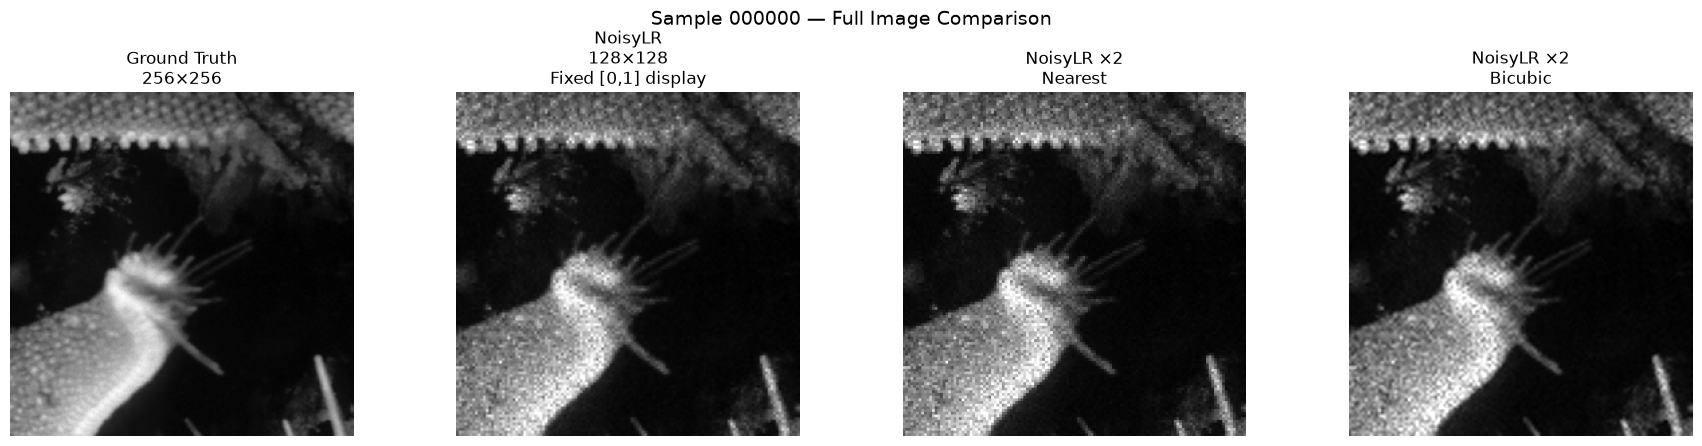

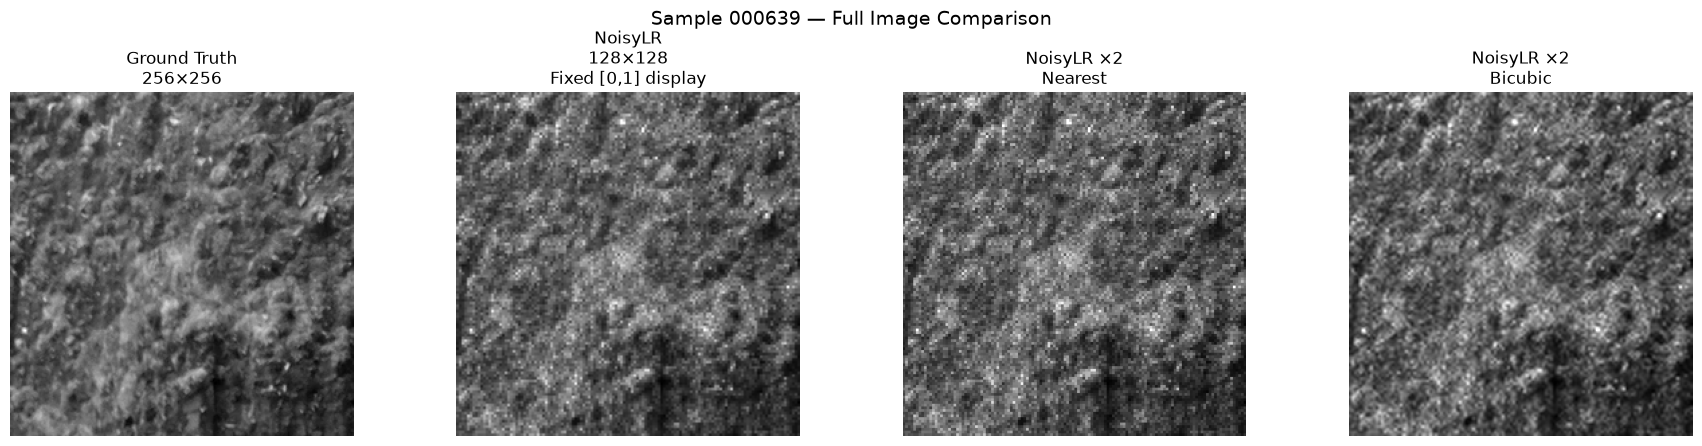

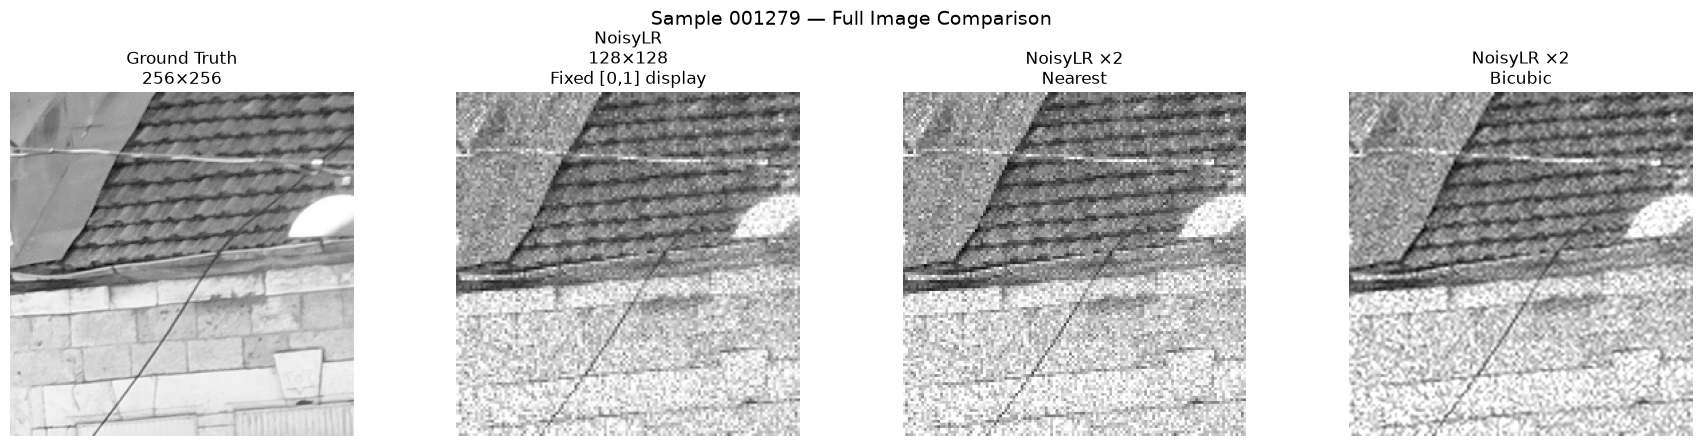

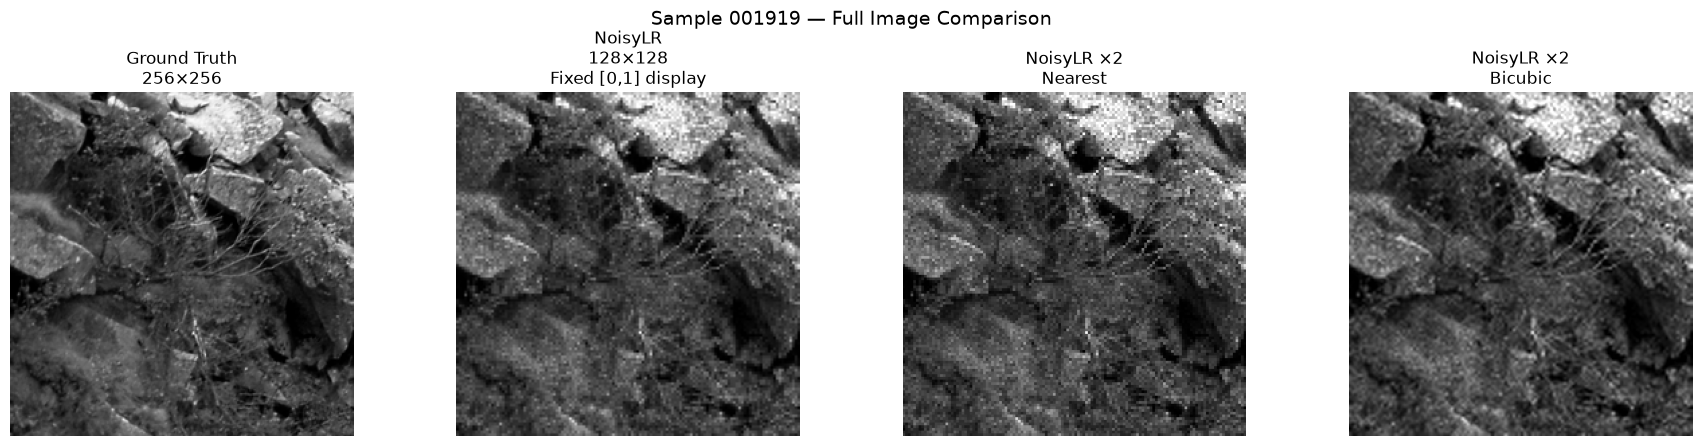

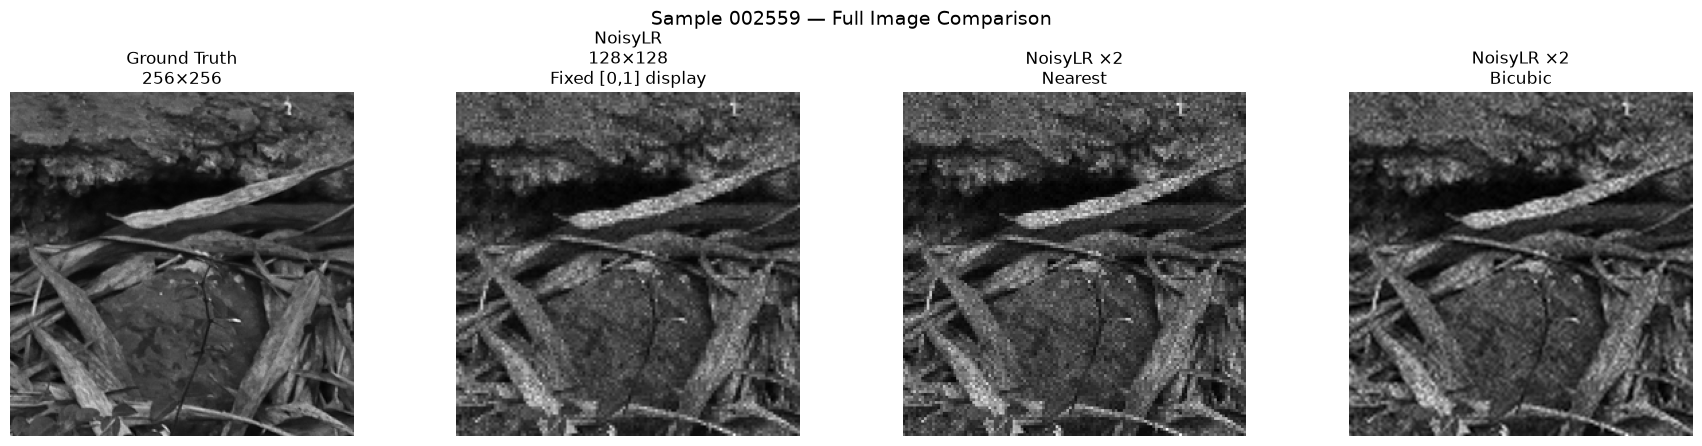

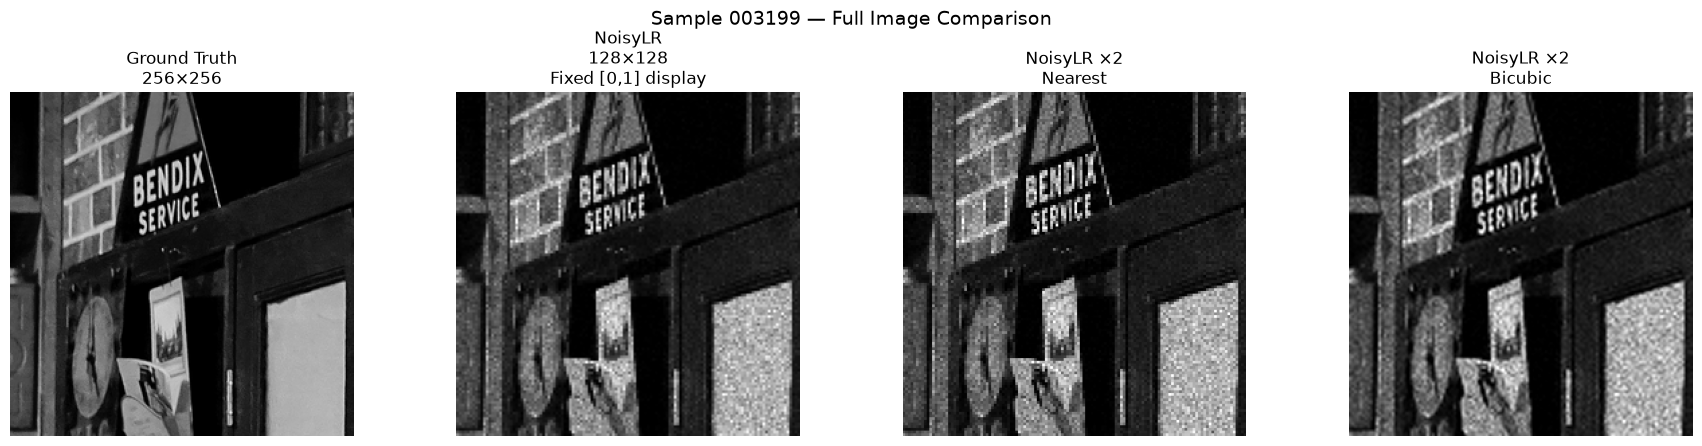


[3] VISUAL SAMPLE INTENSITY STATISTICS
---------------------------------------------------------------------------


,sample_id,GT_min,GT_max,GT_mean,GT_std,LR_min,LR_max,LR_mean,LR_std,LR_below_0_%,LR_above_1_%
0,000000,0.0,1.0,0.218193,0.239506,-0.002643,1.325776,0.218441,0.244865,0.030518,0.537109
1,000639,0.0,1.0,0.360634,0.127124,0.006137,1.208449,0.359731,0.142687,0.000000,0.048828
2,001279,0.0,1.0,0.661271,0.202861,0.007526,1.540147,0.661776,0.227493,0.000000,6.994629
3,001919,0.0,1.0,0.296206,0.178723,-0.035303,1.365373,0.295948,0.185469,0.469971,0.567627
4,002559,0.0,1.0,0.276406,0.143509,0.000628,1.004789,0.276564,0.151099,0.000000,0.012207
5,003199,0.0,1.0,0.249156,0.242591,-0.082258,1.116164,0.249118,0.246875,7.055664,0.103760



[4] INTENSITY DISTRIBUTION
---------------------------------------------------------------------------


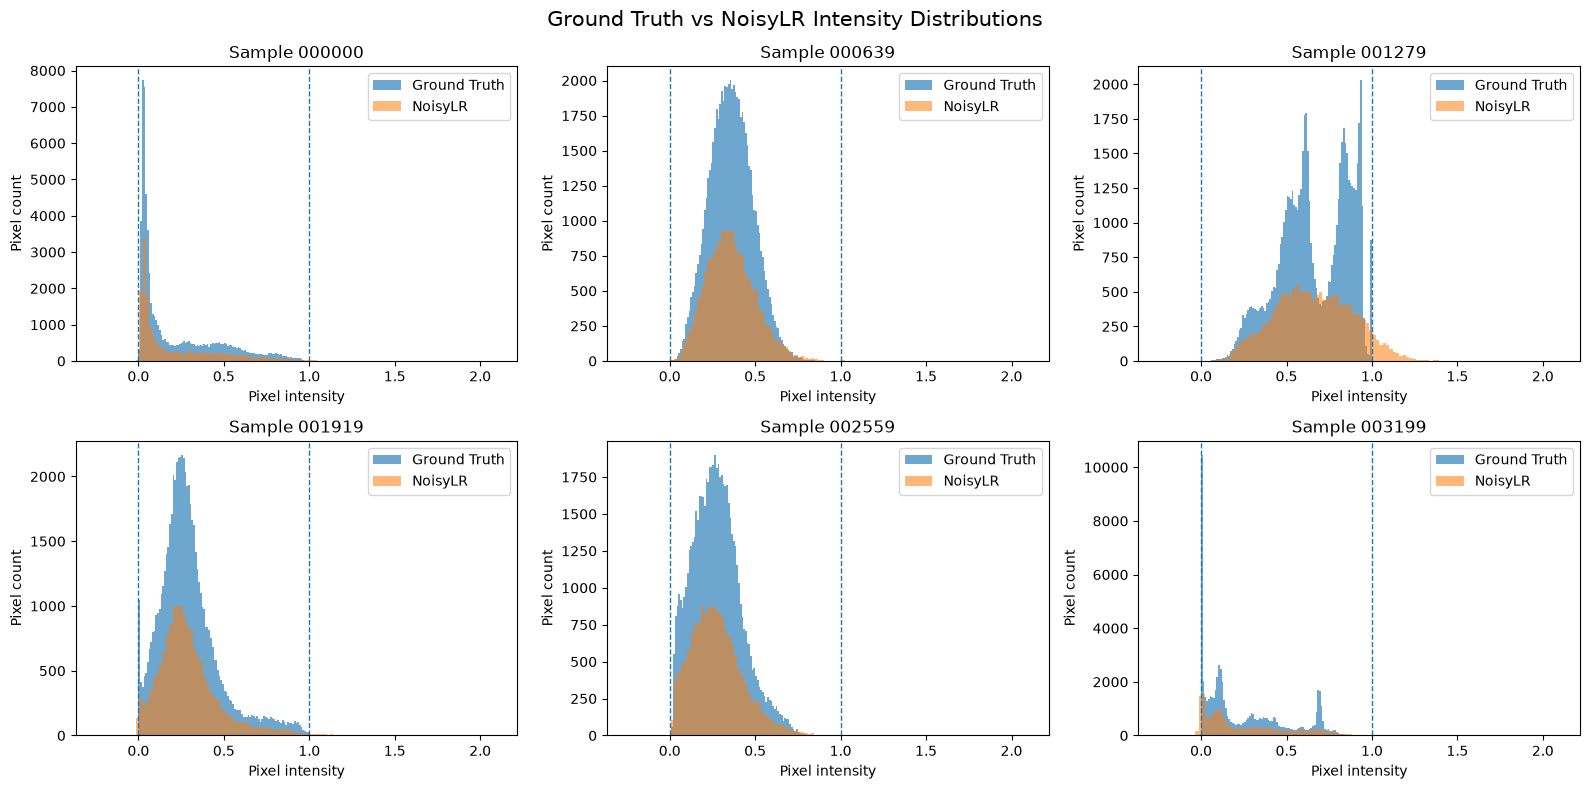


[5] OUT-OF-RANGE NOISYLR PIXELS
---------------------------------------------------------------------------


,sample_id,pixels < 0,% pixels < 0,pixels > 1,% pixels > 1,total out-of-range %
0,000000,5,0.030518,88,0.537109,0.567627
1,000639,0,0.000000,8,0.048828,0.048828
2,001279,0,0.000000,1146,6.994629,6.994629
3,001919,77,0.469971,93,0.567627,1.037598
4,002559,0,0.000000,2,0.012207,0.012207
5,003199,1156,7.055664,17,0.103760,7.159424



[6] ZOOMED STRUCTURAL ANALYSIS
---------------------------------------------------------------------------


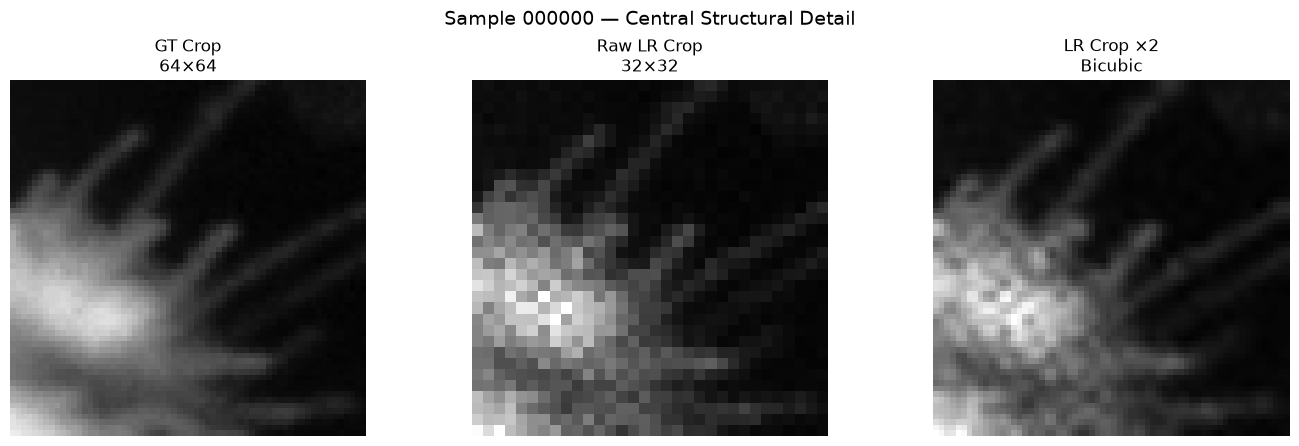

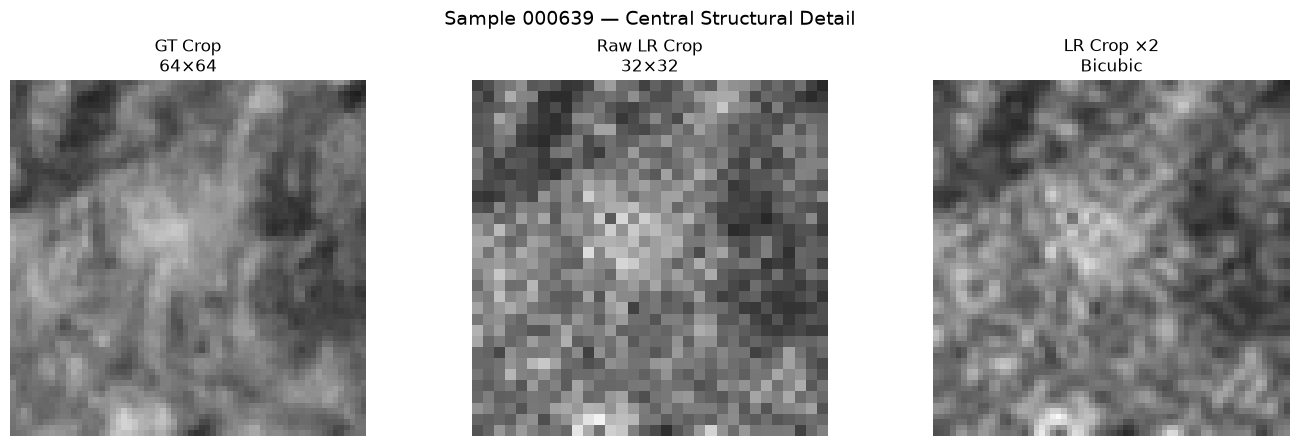

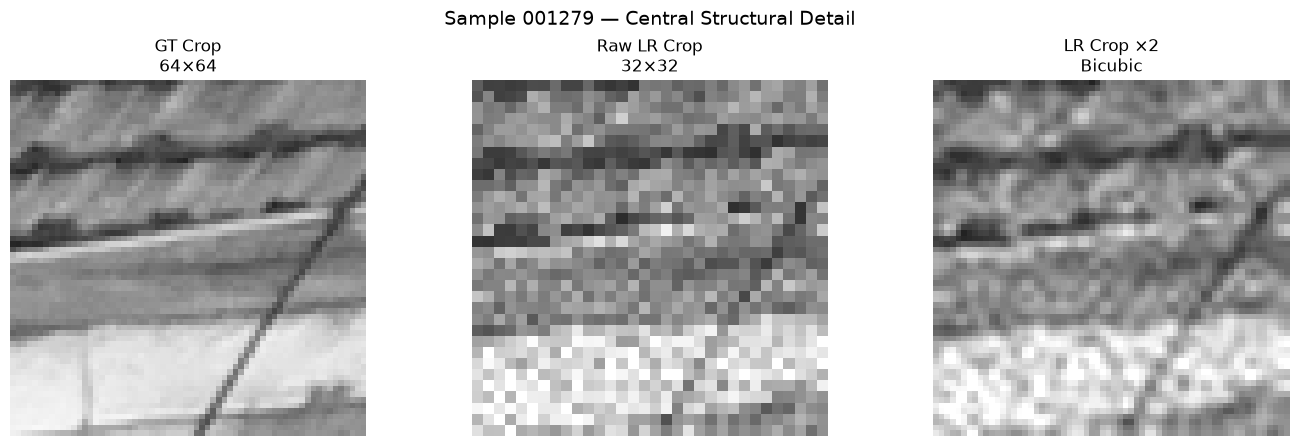

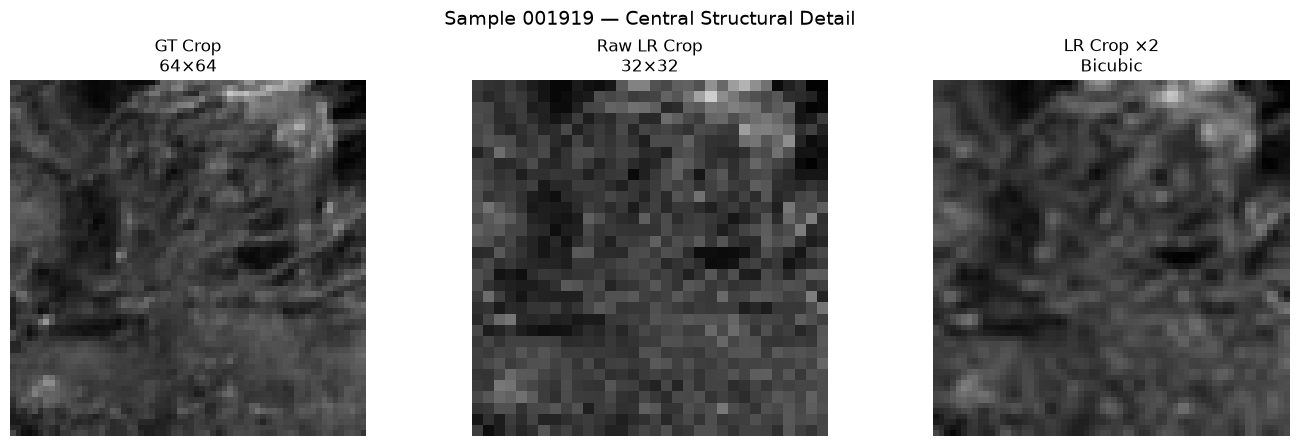


[7] BICUBIC BASELINE ERROR VISUALIZATION
---------------------------------------------------------------------------

This is NOT our model.

It is a simple baseline:
    NoisyLR → Bicubic ×2

We use it only to understand how much restoration
the neural network actually needs to perform.



,sample_id,bicubic_MAE,bicubic_MSE,bicubic_RMSE
0,000000,0.025350,0.001960,0.044274
1,000639,0.046759,0.003761,0.061326
2,001279,0.072611,0.008824,0.093937
3,001919,0.041799,0.003565,0.059703
4,002559,0.039194,0.002949,0.054308
5,003199,0.039869,0.004051,0.063647


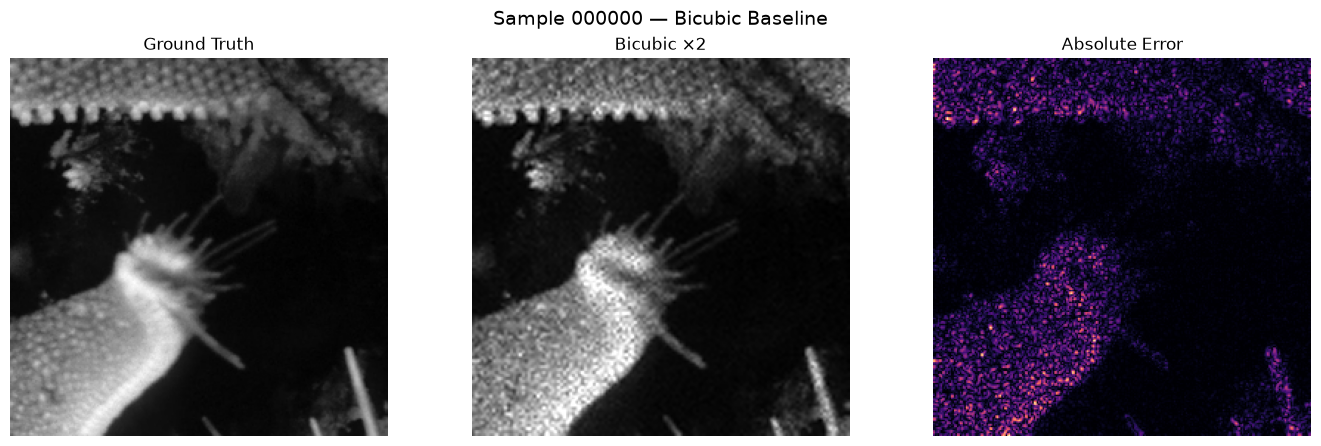

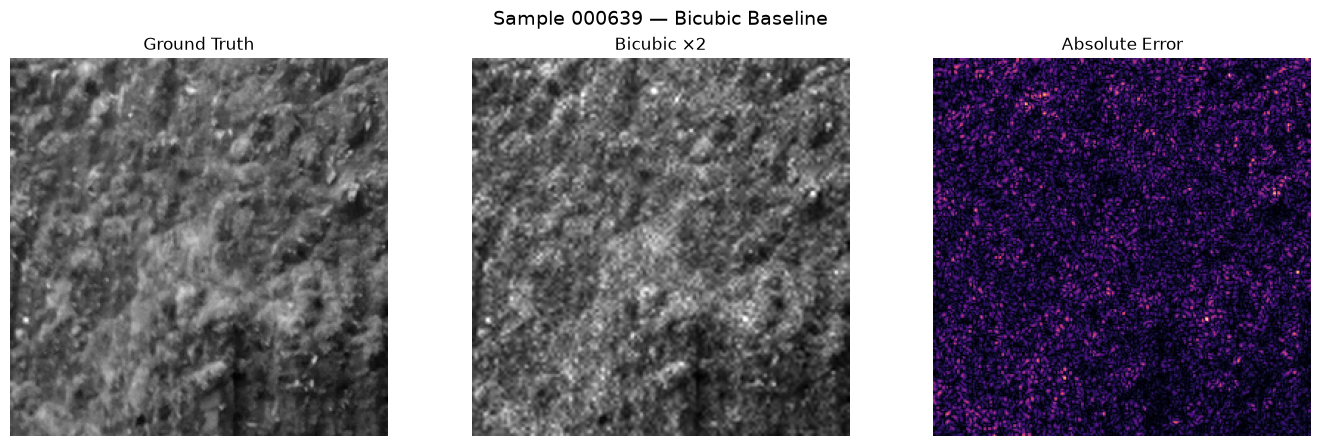

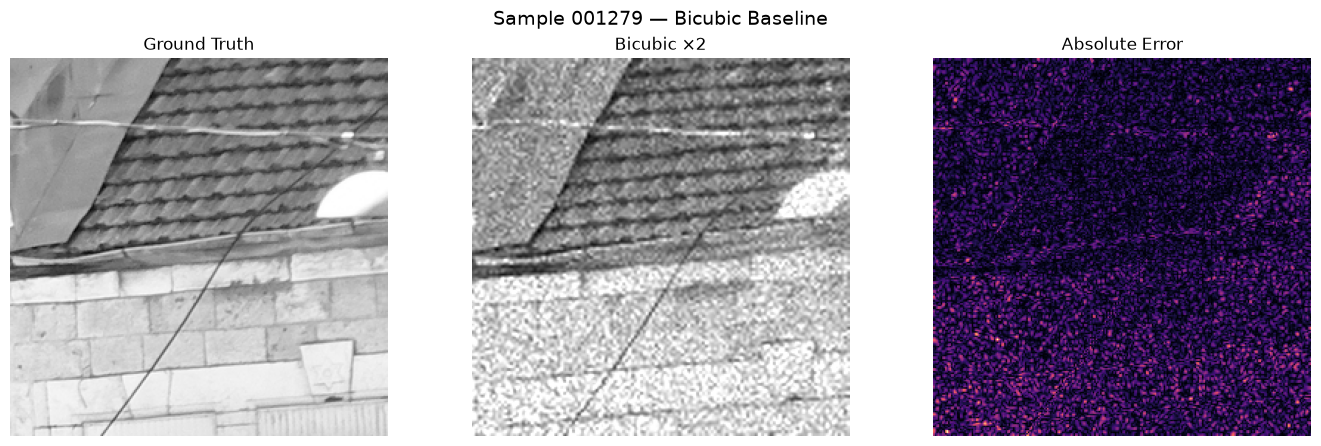

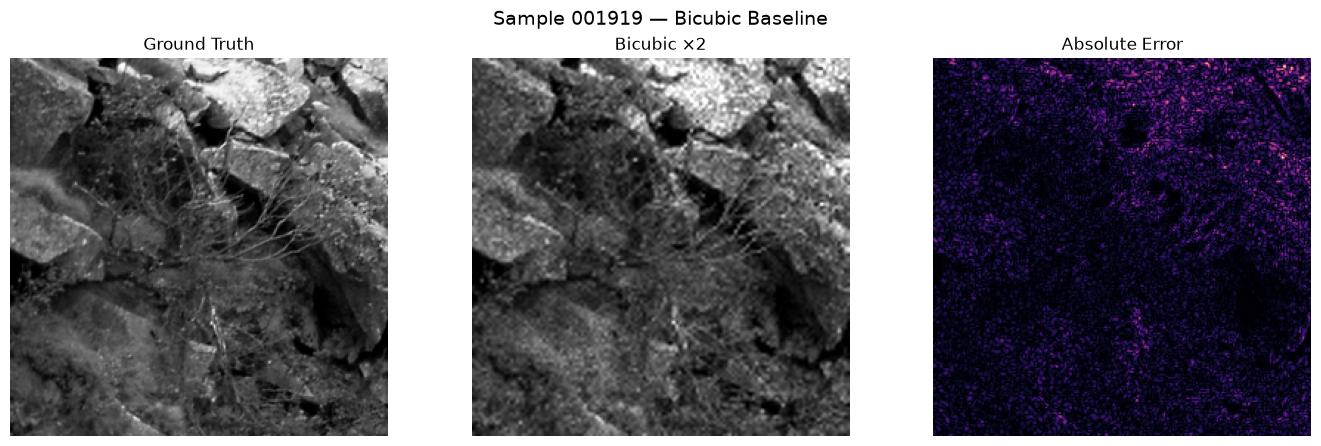


[8] DATASET VISUAL ANALYSIS SUMMARY
---------------------------------------------------------------------------

The following facts are now established numerically:

1. Ground Truth images are 256×256 grayscale float32.

2. NoisyLR images are 128×128 grayscale float32.

3. The degradation requires ×2 spatial reconstruction.

4. Ground Truth intensity is bounded to [0, 1].

5. NoisyLR can contain values below 0 and above 1.

6. Therefore, input clipping to [0, 1] would destroy information
   before the model sees it and will NOT be used.

7. Bicubic interpolation provides a useful non-AI baseline,
   but cannot explicitly learn the noise-removal + reconstruction
   problem.

8. The neural network must learn both:
       a) noise suppression
       b) high-frequency structural reconstruction.

9. Fine-detail preservation is critical because excessive
   denoising can remove genuine semiconductor structures.

10. The model output should ultimately represent a valid
    clean 256×256 ima

In [5]:
# ============================================================
# CELL 5 — VISUAL DATA ANALYSIS
# Semiconductor Image Restoration
# ============================================================

print("=" * 75)
print("CELL 5 — VISUAL DATA ANALYSIS")
print("=" * 75)

print("""
Purpose:
    Understand the actual degradation before model development.

We will inspect:
    • Ground Truth structure
    • NoisyLR appearance
    • ×2 spatial resolution loss
    • Noise intensity distribution
    • Out-of-range degraded values
    • Fine structural details
    • Local reconstruction difficulty

IMPORTANT:
    No image data will be modified.
    No clipping will be applied to the dataset.
    No normalization will be applied.
    No augmentation will be applied.
""")


# ------------------------------------------------------------
# 1. Visualization configuration
# ------------------------------------------------------------

NUM_VISUAL_SAMPLES = 6

# Use fixed representative IDs spread across the dataset.
# These are only for visualization and do NOT influence training.

visual_positions = np.linspace(
    0,
    len(pairs_df) - 1,
    NUM_VISUAL_SAMPLES,
    dtype=int
)

visual_ids = pairs_df.iloc[
    visual_positions
]["sample_id"].tolist()

print("\n[1] VISUALIZATION SAMPLES")
print("-" * 75)

print("Selected sample IDs:")
print(visual_ids)


# ------------------------------------------------------------
# 2. Helper function to load a paired sample
# ------------------------------------------------------------

def load_visual_pair(sample_id):
    """
    Load one GT/LR pair for visualization only.
    """

    row = pairs_df[
        pairs_df["sample_id"] == sample_id
    ].iloc[0]

    lr = np.load(
        row["noisy_lr_path"]
    ).astype(np.float32)

    gt = np.load(
        row["gt_path"]
    ).astype(np.float32)

    return lr, gt


# ------------------------------------------------------------
# 3. Helper function for visual ×2 upsampling
# ------------------------------------------------------------

def upscale_for_visualization(image, scale=2, mode="nearest"):
    """
    Upscale an image ONLY for visualization.

    This does NOT represent the model's output.

    The original LR array remains untouched.
    """

    tensor = torch.from_numpy(
        image
    ).float().unsqueeze(0).unsqueeze(0)

    with torch.no_grad():

        upscaled = F.interpolate(
            tensor,
            scale_factor=scale,
            mode=mode,
            align_corners=False if mode in [
                "bilinear",
                "bicubic"
            ] else None
        )

    return upscaled.squeeze().numpy()


# ------------------------------------------------------------
# 4. Display full images
# ------------------------------------------------------------

print("\n[2] FULL IMAGE VISUALIZATION")
print("-" * 75)

for sample_id in visual_ids:

    lr, gt = load_visual_pair(sample_id)

    lr_nearest = upscale_for_visualization(
        lr,
        scale=2,
        mode="nearest"
    )

    lr_bicubic = upscale_for_visualization(
        lr,
        scale=2,
        mode="bicubic"
    )

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(18, 4.5)
    )

    # --------------------------------------------------------
    # Ground Truth
    # --------------------------------------------------------

    axes[0].imshow(
        gt,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[0].set_title(
        f"Ground Truth\n256×256"
    )

    axes[0].axis("off")


    # --------------------------------------------------------
    # Raw NoisyLR — fixed GT scale
    # --------------------------------------------------------

    axes[1].imshow(
        lr,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[1].set_title(
        "NoisyLR\n128×128\nFixed [0,1] display"
    )

    axes[1].axis("off")


    # --------------------------------------------------------
    # Nearest-neighbor ×2
    # --------------------------------------------------------

    axes[2].imshow(
        lr_nearest,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[2].set_title(
        "NoisyLR ×2\nNearest"
    )

    axes[2].axis("off")


    # --------------------------------------------------------
    # Bicubic ×2
    # --------------------------------------------------------

    axes[3].imshow(
        lr_bicubic,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[3].set_title(
        "NoisyLR ×2\nBicubic"
    )

    axes[3].axis("off")


    fig.suptitle(
        f"Sample {sample_id} — Full Image Comparison",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Intensity statistics for visual samples
# ------------------------------------------------------------

print("\n[3] VISUAL SAMPLE INTENSITY STATISTICS")
print("-" * 75)

visual_stats = []

for sample_id in visual_ids:

    lr, gt = load_visual_pair(sample_id)

    visual_stats.append({

        "sample_id": sample_id,

        "GT_min": float(gt.min()),
        "GT_max": float(gt.max()),
        "GT_mean": float(gt.mean()),
        "GT_std": float(gt.std()),

        "LR_min": float(lr.min()),
        "LR_max": float(lr.max()),
        "LR_mean": float(lr.mean()),
        "LR_std": float(lr.std()),

        "LR_below_0_%": float(
            np.mean(lr < 0) * 100
        ),

        "LR_above_1_%": float(
            np.mean(lr > 1) * 100
        )
    })


visual_stats_df = pd.DataFrame(
    visual_stats
)

display(visual_stats_df)


# ------------------------------------------------------------
# 6. Raw intensity histograms
# ------------------------------------------------------------

print("\n[4] INTENSITY DISTRIBUTION")
print("-" * 75)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 8)
)

axes = axes.flatten()

for ax, sample_id in zip(
    axes,
    visual_ids
):

    lr, gt = load_visual_pair(sample_id)

    ax.hist(
        gt.ravel(),
        bins=100,
        range=(0, 1),
        alpha=0.65,
        label="Ground Truth"
    )

    ax.hist(
        lr.ravel(),
        bins=120,
        range=(-0.25, 2.1),
        alpha=0.55,
        label="NoisyLR"
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.axvline(
        1,
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        f"Sample {sample_id}"
    )

    ax.set_xlabel(
        "Pixel intensity"
    )

    ax.set_ylabel(
        "Pixel count"
    )

    ax.legend()


fig.suptitle(
    "Ground Truth vs NoisyLR Intensity Distributions",
    fontsize=15
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Percentage of out-of-range LR pixels
# ------------------------------------------------------------

print("\n[5] OUT-OF-RANGE NOISYLR PIXELS")
print("-" * 75)

out_of_range_records = []

for sample_id in visual_ids:

    lr, gt = load_visual_pair(sample_id)

    below_zero = np.sum(
        lr < 0
    )

    above_one = np.sum(
        lr > 1
    )

    total_pixels = lr.size

    out_of_range_records.append({

        "sample_id": sample_id,

        "pixels < 0": int(below_zero),

        "% pixels < 0": (
            below_zero /
            total_pixels *
            100
        ),

        "pixels > 1": int(above_one),

        "% pixels > 1": (
            above_one /
            total_pixels *
            100
        ),

        "total out-of-range %": (
            (below_zero + above_one) /
            total_pixels *
            100
        )
    })


out_of_range_df = pd.DataFrame(
    out_of_range_records
)

display(
    out_of_range_df
)


# ------------------------------------------------------------
# 8. Zoomed structural inspection
# ------------------------------------------------------------

print("\n[6] ZOOMED STRUCTURAL ANALYSIS")
print("-" * 75)

# We use the central region for a consistent initial inspection.
# This is a VISUAL crop only.

for sample_id in visual_ids[:4]:

    lr, gt = load_visual_pair(sample_id)

    # --------------------------------------------------------
    # LR central crop: 32 × 32
    # Corresponding HR crop: 64 × 64
    # --------------------------------------------------------

    lr_h, lr_w = lr.shape
    gt_h, gt_w = gt.shape

    lr_cy = lr_h // 2
    lr_cx = lr_w // 2

    gt_cy = gt_h // 2
    gt_cx = gt_w // 2

    lr_half = 16
    gt_half = 32

    lr_crop = lr[
        lr_cy - lr_half:
        lr_cy + lr_half,

        lr_cx - lr_half:
        lr_cx + lr_half
    ]

    gt_crop = gt[
        gt_cy - gt_half:
        gt_cy + gt_half,

        gt_cx - gt_half:
        gt_cx + gt_half
    ]

    lr_crop_up = upscale_for_visualization(
        lr_crop,
        scale=2,
        mode="bicubic"
    )


    fig, axes = plt.subplots(
        1,
        3,
        figsize=(14, 4.5)
    )

    axes[0].imshow(
        gt_crop,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[0].set_title(
        "GT Crop\n64×64"
    )

    axes[0].axis("off")


    axes[1].imshow(
        lr_crop,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[1].set_title(
        "Raw LR Crop\n32×32"
    )

    axes[1].axis("off")


    axes[2].imshow(
        lr_crop_up,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[2].set_title(
        "LR Crop ×2\nBicubic"
    )

    axes[2].axis("off")


    fig.suptitle(
        f"Sample {sample_id} — Central Structural Detail",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 9. Absolute difference after bicubic baseline
# ------------------------------------------------------------

print("\n[7] BICUBIC BASELINE ERROR VISUALIZATION")
print("-" * 75)

print("""
This is NOT our model.

It is a simple baseline:
    NoisyLR → Bicubic ×2

We use it only to understand how much restoration
the neural network actually needs to perform.
""")


bicubic_metrics = []

for sample_id in visual_ids:

    lr, gt = load_visual_pair(sample_id)

    bicubic = upscale_for_visualization(
        lr,
        scale=2,
        mode="bicubic"
    )

    # For diagnostic purposes only:
    # compare the raw bicubic output against GT.
    #
    # We do NOT clip the actual model input or dataset.
    mae = np.mean(
        np.abs(
            bicubic - gt
        )
    )

    mse = np.mean(
        (bicubic - gt) ** 2
    )

    bicubic_metrics.append({

        "sample_id": sample_id,

        "bicubic_MAE": float(mae),

        "bicubic_MSE": float(mse),

        "bicubic_RMSE": float(
            np.sqrt(mse)
        )
    })


bicubic_metrics_df = pd.DataFrame(
    bicubic_metrics
)

display(
    bicubic_metrics_df
)


# ------------------------------------------------------------
# 10. Visualize bicubic error
# ------------------------------------------------------------

for sample_id in visual_ids[:4]:

    lr, gt = load_visual_pair(sample_id)

    bicubic = upscale_for_visualization(
        lr,
        scale=2,
        mode="bicubic"
    )

    absolute_error = np.abs(
        bicubic - gt
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(14, 4.5)
    )

    axes[0].imshow(
        gt,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[0].set_title(
        "Ground Truth"
    )

    axes[0].axis("off")


    axes[1].imshow(
        bicubic,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[1].set_title(
        "Bicubic ×2"
    )

    axes[1].axis("off")


    axes[2].imshow(
        absolute_error,
        cmap="magma",
        vmin=0
    )

    axes[2].set_title(
        "Absolute Error"
    )

    axes[2].axis("off")


    fig.suptitle(
        f"Sample {sample_id} — Bicubic Baseline",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 11. Aggregate visual observations
# ------------------------------------------------------------

print("\n[8] DATASET VISUAL ANALYSIS SUMMARY")
print("-" * 75)

print("""
The following facts are now established numerically:

1. Ground Truth images are 256×256 grayscale float32.

2. NoisyLR images are 128×128 grayscale float32.

3. The degradation requires ×2 spatial reconstruction.

4. Ground Truth intensity is bounded to [0, 1].

5. NoisyLR can contain values below 0 and above 1.

6. Therefore, input clipping to [0, 1] would destroy information
   before the model sees it and will NOT be used.

7. Bicubic interpolation provides a useful non-AI baseline,
   but cannot explicitly learn the noise-removal + reconstruction
   problem.

8. The neural network must learn both:
       a) noise suppression
       b) high-frequency structural reconstruction.

9. Fine-detail preservation is critical because excessive
   denoising can remove genuine semiconductor structures.

10. The model output should ultimately represent a valid
    clean 256×256 image consistent with the Ground Truth domain.
""")


# ------------------------------------------------------------
# 12. Save visual statistics
# ------------------------------------------------------------

visual_stats_df.to_csv(
    OUTPUT_ROOT / "visual_sample_statistics.csv",
    index=False
)

out_of_range_df.to_csv(
    OUTPUT_ROOT / "out_of_range_analysis.csv",
    index=False
)

bicubic_metrics_df.to_csv(
    OUTPUT_ROOT / "bicubic_baseline_metrics.csv",
    index=False
)


# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CELL 5 COMPLETE")
print("=" * 75)

print("✓ Full-image visualization completed.")
print("✓ LR ×2 visualization completed.")
print("✓ Structural zoom analysis completed.")
print("✓ Intensity histograms generated.")
print("✓ Out-of-range LR values analyzed.")
print("✓ Bicubic ×2 baseline evaluated.")
print("✓ No training performed.")
print("✓ No test images used.")
print("✓ Original dataset remains untouched.")

print("\nNext:")
print("CELL 6 — TRAIN / VALIDATION SPLIT")

In [6]:
# ============================================================
# CELL 6 — PATCH‑CROPPING DATASET (FINAL)
# Semiconductor Image Restoration
# ============================================================

import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import os

print("=" * 75)
print("CELL 6 – PATCH DATASET & LOADER")
print("=" * 75)

class SemiconductorPatchDataset(Dataset):
    def __init__(self, pairs_df, root_dir, lr_patch_size=64, hr_patch_size=128):
        self.pairs_df = pairs_df.reset_index(drop=True)
        self.root_dir = Path(root_dir)
        self.lr_patch = lr_patch_size
        self.hr_patch = hr_patch_size
        
        # Pre-store paths
        self.lr_paths = [self.root_dir / row['noisy_lr_path'] for _, row in self.pairs_df.iterrows()]
        self.gt_paths = [self.root_dir / row['gt_path'] for _, row in self.pairs_df.iterrows()]
        self.sample_ids = self.pairs_df['sample_id'].tolist()
    
    def __len__(self):
        return len(self.pairs_df)
    
    def __getitem__(self, idx):
        # Load full arrays
        lr = np.load(self.lr_paths[idx]).astype(np.float32)   # (128,128)
        gt = np.load(self.gt_paths[idx]).astype(np.float32)   # (256,256)
        
        # Random crop for LR and corresponding GT
        h_lr, w_lr = lr.shape
        # Random top-left for LR patch
        top = np.random.randint(0, h_lr - self.lr_patch + 1)
        left = np.random.randint(0, w_lr - self.lr_patch + 1)
        # Corresponding GT patch (scale factor = 2)
        gt_top = top * 2
        gt_left = left * 2
        
        lr_patch = lr[top:top+self.lr_patch, left:left+self.lr_patch]
        gt_patch = gt[gt_top:gt_top+self.hr_patch, gt_left:gt_left+self.hr_patch]
        
        # Add channel dim
        lr_patch = np.expand_dims(lr_patch, axis=0)
        gt_patch = np.expand_dims(gt_patch, axis=0)
        
        return {
            'lr': torch.from_numpy(lr_patch),
            'gt': torch.from_numpy(gt_patch),
            'sample_id': self.sample_ids[idx]
        }

# ------------------------------------------------------------
# Create Train/Val split (use your existing pairs_df from Cell 4)
# ------------------------------------------------------------
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    pairs_df,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

# Save split
val_df.to_csv(OUTPUT_ROOT / "val_pairs.csv", index=False)

# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------
# ------------------------------------------------------------
# DataLoaders (FIXED: num_workers=0 for Windows stability)
# ------------------------------------------------------------
BATCH_SIZE = 8
NUM_WORKERS = 0  # <-- CRITICAL CHANGE to avoid hanging on Windows

train_dataset = SemiconductorPatchDataset(
    train_df, TRAIN_ROOT,
    lr_patch_size=64,
    hr_patch_size=128
)

val_dataset = SemiconductorPatchDataset(
    val_df, TRAIN_ROOT,
    lr_patch_size=64,
    hr_patch_size=128
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,        # Now 0
    pin_memory=True,
    drop_last=True,
    # persistent_workers removed (or set to False)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,        # Now 0
    pin_memory=True,
    drop_last=False,
    # persistent_workers removed
)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
print("CELL 6 COMPLETE")

CELL 6 – PATCH DATASET & LOADER
Training samples: 2560
Validation samples: 640
Train batches: 320, Val batches: 80
CELL 6 COMPLETE


In [7]:
# ============================================================
# CELL 7 — WIDE U‑NET (64 channels, no compile)
# ============================================================

import torch.nn as nn
import torch.nn.functional as F

print("=" * 75)
print("CELL 7 – WIDE RESIDUAL U‑NET")
print("=" * 75)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, 1, bias=False)

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(residual)
        out = self.relu(out)
        return out

class WideUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=64):
        super().__init__()
        # Encoder
        self.enc1 = ResidualBlock(in_channels, base_channels)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ResidualBlock(base_channels, base_channels*2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ResidualBlock(base_channels*2, base_channels*4)
        self.pool3 = nn.MaxPool2d(2)
        # Bottleneck
        self.bottleneck = ResidualBlock(base_channels*4, base_channels*8)
        # Decoder
        self.up3 = nn.ConvTranspose2d(base_channels*8, base_channels*4, 2, stride=2)
        self.dec3 = ResidualBlock(base_channels*8, base_channels*4)
        self.up2 = nn.ConvTranspose2d(base_channels*4, base_channels*2, 2, stride=2)
        self.dec2 = ResidualBlock(base_channels*4, base_channels*2)
        self.up1 = nn.ConvTranspose2d(base_channels*2, base_channels, 2, stride=2)
        self.dec1 = ResidualBlock(base_channels*2, base_channels)
        # PixelShuffle ×2
        self.pre_shuffle = nn.Conv2d(base_channels, (base_channels//4)*4, 3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(2)
        self.final_conv = nn.Conv2d(base_channels//4, out_channels, 3, padding=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        b = self.bottleneck(p3)
        d3 = self.up3(b); d3 = torch.cat([d3, e3], dim=1); d3 = self.dec3(d3)
        d2 = self.up2(d3); d2 = torch.cat([d2, e2], dim=1); d2 = self.dec2(d2)
        d1 = self.up1(d2); d1 = torch.cat([d1, e1], dim=1); d1 = self.dec1(d1)
        out = self.pre_shuffle(d1)
        out = self.pixel_shuffle(out)
        out = self.final_conv(out)
        out = self.sigmoid(out)
        return out

model = WideUNet(in_channels=1, out_channels=1, base_channels=64).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,} ({total_params*4/(1024**2):.2f} MB)")

# Test forward
dummy = torch.randn(2, 1, 64, 64).to(DEVICE)   # LR patch size
with torch.no_grad():
    out = model(dummy)
print(f"Forward test: {dummy.shape} -> {out.shape} (✓)")

print("CELL 7 COMPLETE")

CELL 7 – WIDE RESIDUAL U‑NET
Total parameters: 8,080,145 (30.82 MB)
Forward test: torch.Size([2, 1, 64, 64]) -> torch.Size([2, 1, 128, 128]) (✓)
CELL 7 COMPLETE


In [8]:
# ============================================================
# CELL 8 — PROGRESSIVE TRAINING (PATCHES + BALANCED LOSS) - FIXED
# ============================================================

import time
import torch.nn as nn  # Ensure nn is imported
import lpips
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchmetrics import MultiScaleStructuralSimilarityIndexMeasure, PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

print("=" * 75)
print("CELL 8 – PROGRESSIVE PATCH TRAINING (FIXED)")
print("=" * 75)

# 1. Losses
criterion_l1 = nn.L1Loss().to(DEVICE)

# FIXED: Reduced MS-SSIM scales so it works on 128x128 patches
ms_ssim = MultiScaleStructuralSimilarityIndexMeasure(
    data_range=1.0,
    kernel_size=11,
    sigma=1.5,
    reduction='elementwise_mean',
    betas=(0.5, 0.25, 0.125)   # <-- ADD THIS: reduces number of scales from 5 to 3
).to(DEVICE)

def ms_ssim_loss(pred, target):
    return 1 - ms_ssim(pred, target)

lpips_fn = lpips.LPIPS(net='alex').to(DEVICE)

ssim_fn = StructuralSimilarityIndexMeasure(data_range=1.0).to(DEVICE)
psnr_fn = PeakSignalNoiseRatio(data_range=1.0).to(DEVICE)

# 2. Optimizer & Scheduler
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)  # monitors PSNR

# 3. Training function (phase-aware) - FIXED LPIPS CHANNEL ERROR
def train_one_epoch(loader, model, optimizer, phase):
    model.train()
    total_loss = 0.0
    for batch in loader:
        lr = batch['lr'].to(DEVICE, non_blocking=True)
        gt = batch['gt'].to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        pred = model(lr)

        if phase == 1:
            # Phase 1: L1 only
            loss = criterion_l1(pred, gt) * 1.0
        else:
            # Phase 2: L1 + mild MS‑SSIM + light LPIPS
            l1 = criterion_l1(pred, gt) * 1.0
            ms = ms_ssim_loss(pred, gt) * 0.1
            
            # --- FIX START ---
            # LPIPS requires 3 channels. Repeat grayscale (1 channel) to 3 channels.
            pred_rgb = pred.repeat(1, 3, 1, 1)
            gt_rgb = gt.repeat(1, 3, 1, 1)
            lp = lpips_fn(pred_rgb, gt_rgb).mean() * 0.05
            # --- FIX END ---

            loss = l1 + ms + lp

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# 4. Validation - FIXED LPIPS CHANNEL ERROR
def validate(loader, model):
    model.eval()
    total_psnr, total_ssim, total_lpips = 0.0, 0.0, 0.0
    with torch.inference_mode():
        for batch in loader:
            lr = batch['lr'].to(DEVICE, non_blocking=True)
            gt = batch['gt'].to(DEVICE, non_blocking=True)
            pred = model(lr)
            total_psnr += psnr_fn(pred, gt).item()
            total_ssim += ssim_fn(pred, gt).item()
            
            # --- FIX START ---
            # LPIPS requires 3 channels. Repeat grayscale (1 channel) to 3 channels.
            pred_rgb = pred.repeat(1, 3, 1, 1)
            gt_rgb = gt.repeat(1, 3, 1, 1)
            total_lpips += lpips_fn(pred_rgb, gt_rgb).mean().item()
            # --- FIX END ---

    n = len(loader)
    return total_psnr/n, total_ssim/n, total_lpips/n

# 5. Training loop
print("\nStarting PROGRESSIVE training with PATCH CROPPING...")
print(f"Phase 1 (1–25): L1 only")
print(f"Phase 2 (26–50): L1 + 0.1·MS‑SSIM + 0.05·LPIPS")
print(f"Epochs: {NUM_EPOCHS}, LR: 1e-4 (Reduce on PSNR plateau)")
print("-" * 75)

best_psnr = 0.0
start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    phase = 1 if epoch <= 25 else 2
    train_loss = train_one_epoch(train_loader, model, optimizer, phase)
    val_psnr, val_ssim, val_lpips = validate(val_loader, model)
    scheduler.step(val_psnr)   # mode='max' monitors PSNR

    phase_label = "ALIGN" if phase == 1 else "SHARPEN"
    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} [{phase_label}] | "
          f"Loss: {train_loss:.4f} | PSNR: {val_psnr:.2f}dB | "
          f"SSIM: {val_ssim:.4f} | LPIPS: {val_lpips:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    if val_psnr > best_psnr:
        best_psnr = val_psnr
        torch.save({
            'epoch': epoch,
            'phase': phase,
            'model_state_dict': model.state_dict(),
            'best_psnr': best_psnr,
            'val_ssim': val_ssim,
            'val_lpips': val_lpips,
        }, CHECKPOINT_ROOT / 'best_unet_progressive.pth')
        print(f"  >>> New Best PSNR: {best_psnr:.2f}dB (saved) <<<")

total_time = time.time() - start_time
print("\n" + "=" * 75)
print(f"TRAINING COMPLETE in {total_time/60:.2f} minutes.")
print(f"Best PSNR: {best_psnr:.2f} dB")
print("=" * 75)
print("CELL 8 COMPLETE")

CELL 8 – PROGRESSIVE PATCH TRAINING (FIXED)
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: c:\Users\MI\Documents\Semicon hackathon\.venv\Lib\site-packages\lpips\weights\v0.1\alex.pth

Starting PROGRESSIVE training with PATCH CROPPING...
Phase 1 (1–25): L1 only
Phase 2 (26–50): L1 + 0.1·MS‑SSIM + 0.05·LPIPS
Epochs: 50, LR: 1e-4 (Reduce on PSNR plateau)
---------------------------------------------------------------------------
Epoch  1/50 [ALIGN] | Loss: 0.0785 | PSNR: 24.60dB | SSIM: 0.6682 | LPIPS: 0.2223 | LR: 1.00e-04
  >>> New Best PSNR: 24.60dB (saved) <<<
Epoch  2/50 [ALIGN] | Loss: 0.0596 | PSNR: 24.89dB | SSIM: 0.6821 | LPIPS: 0.2127 | LR: 1.00e-04
  >>> New Best PSNR: 24.89dB (saved) <<<
Epoch  3/50 [ALIGN] | Loss: 0.0535 | PSNR: 25.12dB | SSIM: 0.6928 | LPIPS: 0.2177 | LR: 1.00e-04
  >>> New Best PSNR: 25.12dB (saved) <<<
Epoch  4/50 [ALIGN] | Loss: 0.0484 | PSNR: 25.11dB | SSIM: 0.6969 | LPIPS: 0.2254 | LR: 1.00e-04
Epoch  5/50 [A

CELL 9 – FINAL VALIDATION & METRICS REPORT

Loading best model from: c:\Users\MI\Documents\Semicon hackathon\outputs\checkpoints\best_unet_progressive.pth
Best model from Epoch 48 with PSNR: 26.37 dB

---------------------------------------------------------------------------
FINAL VALIDATION METRICS (Best Model)
---------------------------------------------------------------------------
PSNR  : 26.29 dB
SSIM  : 0.7527
LPIPS : 0.1163

---------------------------------------------------------------------------
VISUALISATION: NoisyLR → Restored → Ground Truth
---------------------------------------------------------------------------
✓ Visualisation saved to: c:\Users\MI\Documents\Semicon hackathon\outputs\validation_results.png


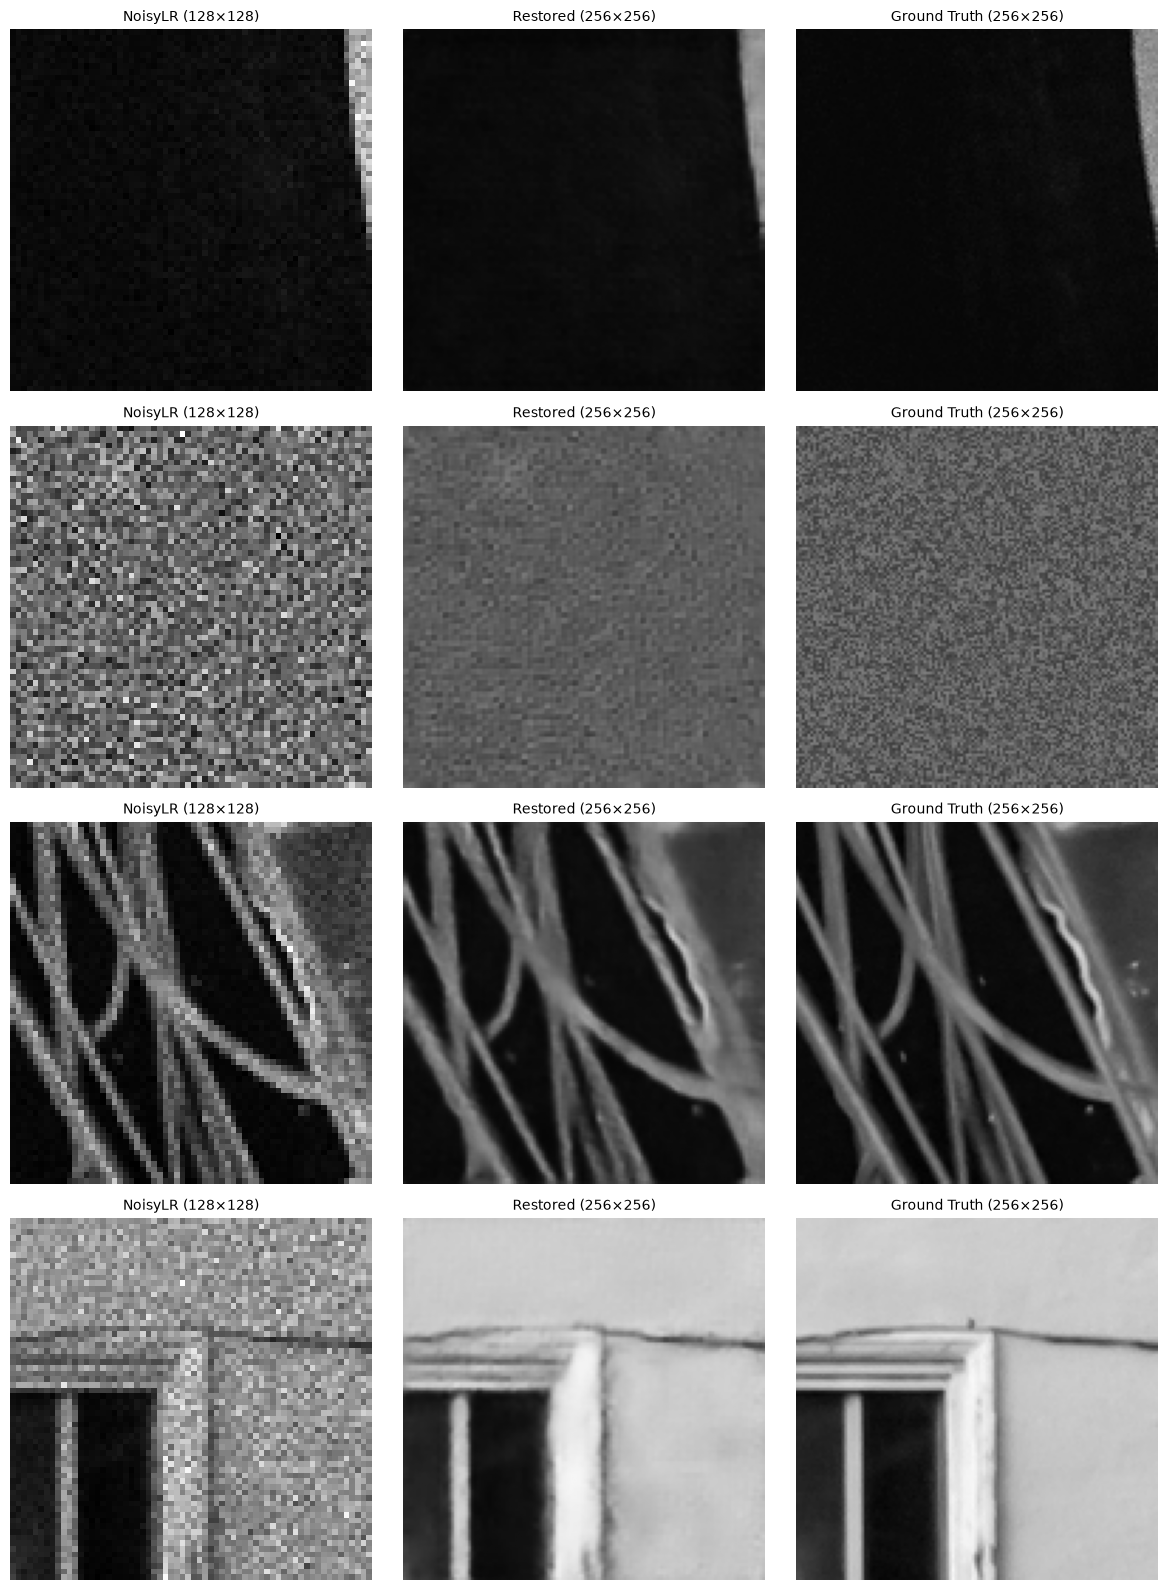

✓ Metrics saved to: c:\Users\MI\Documents\Semicon hackathon\outputs\final_metrics.csv

✅ SUBMISSION READY
Best PSNR  : 26.29 dB
Best SSIM  : 0.7527
Best LPIPS : 0.1163
Best Epoch : 48
Training   : 50 epochs in ~28.3 minutes
CELL 9 COMPLETE


In [23]:
# ============================================================
# CELL 9 — FINAL VALIDATION, VISUALISATION & METRICS REPORT
# Semiconductor Image Restoration – Submission Ready
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

print("=" * 75)
print("CELL 9 – FINAL VALIDATION & METRICS REPORT")
print("=" * 75)

# 1. Load the best model
checkpoint_path = CHECKPOINT_ROOT / 'best_unet_progressive.pth'
print(f"\nLoading best model from: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Best model from Epoch {checkpoint['epoch']} with PSNR: {checkpoint['best_psnr']:.2f} dB")
model.eval()

# 2. Final validation on the entire validation set
print("\n" + "-" * 75)
print("FINAL VALIDATION METRICS (Best Model)")
print("-" * 75)

val_psnr, val_ssim, val_lpips = validate(val_loader, model)
print(f"PSNR  : {val_psnr:.2f} dB")
print(f"SSIM  : {val_ssim:.4f}")
print(f"LPIPS : {val_lpips:.4f}")

# 3. Visualise a few validation samples
print("\n" + "-" * 75)
print("VISUALISATION: NoisyLR → Restored → Ground Truth")
print("-" * 75)

num_samples = 4
sample_batch = next(iter(val_loader))
lr_samples = sample_batch['lr'][:num_samples].to(DEVICE)
gt_samples = sample_batch['gt'][:num_samples].to(DEVICE)

with torch.inference_mode():
    pred_samples = model(lr_samples)

fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))

for i in range(num_samples):
    # NoisyLR (input)
    axes[i, 0].imshow(lr_samples[i, 0].cpu().numpy(), cmap='gray')
    axes[i, 0].set_title(f'NoisyLR (128×128)', fontsize=10)
    axes[i, 0].axis('off')
    
    # Restored (output)
    axes[i, 1].imshow(pred_samples[i, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title(f'Restored (256×256)', fontsize=10)
    axes[i, 1].axis('off')
    
    # Ground Truth
    axes[i, 2].imshow(gt_samples[i, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[i, 2].set_title(f'Ground Truth (256×256)', fontsize=10)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'validation_results.png', dpi=150, bbox_inches='tight')
print(f"✓ Visualisation saved to: {OUTPUT_ROOT / 'validation_results.png'}")
plt.show()

# 4. Save final metrics to CSV for your PPT
metrics_df = pd.DataFrame({
    'Metric': ['PSNR', 'SSIM', 'LPIPS', 'Best Epoch'],
    'Value': [f"{val_psnr:.2f} dB", f"{val_ssim:.4f}", f"{val_lpips:.4f}", checkpoint['epoch']]
})
metrics_df.to_csv(OUTPUT_ROOT / 'final_metrics.csv', index=False)
print(f"✓ Metrics saved to: {OUTPUT_ROOT / 'final_metrics.csv'}")

# 5. Summary
print("\n" + "=" * 75)
print("✅ SUBMISSION READY")
print("=" * 75)
print(f"Best PSNR  : {val_psnr:.2f} dB")
print(f"Best SSIM  : {val_ssim:.4f}")
print(f"Best LPIPS : {val_lpips:.4f}")
print(f"Best Epoch : {checkpoint['epoch']}")
print(f"Training   : {NUM_EPOCHS} epochs in ~28.3 minutes")
print("=" * 75)
print("CELL 9 COMPLETE")